In [1]:
import sys 
import os 

sys.path.append(os.path.join('..', '..'))

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.base import clone 
from sklearn.linear_model import TweedieRegressor, PoissonRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import ParameterSampler

In [3]:
data_dir = Path("../../data/base_de_dados_final/")
arquivo = data_dir / "base_feature_engineering.csv"

In [4]:
df_ml = pd.read_csv(arquivo, sep=";", encoding="latin1", dtype=str)

In [5]:
df_ml.head()

,ATENDIMENTO_BAIRRO_NOME,FLAG_EQUIPAMENTO_URBANO,FLAG_FLAGRANTE,NATUREZA1_DEFESA_CIVIL,NATUREZA2_DEFESA_CIVIL,NATUREZA3_DEFESA_CIVIL,NATUREZA4_DEFESA_CIVIL,NATUREZA5_DEFESA_CIVIL,OCORRENCIA_DIA_SEMANA,OCORRENCIA_MES,...,OUTROS,log_rendimento,log_pop,rendimento_medio_responsavel_sm_estimado_norm,pct_alfabetizacao_15mais_estimado_norm,pct_sem_banheiro_sanitario_estimado_norm,pct_esgotamento_precario_estimado_norm,pct_sem_rede_geral_agua_estimado_norm,pct_lixo_destino_inadequado_estimado_norm,IQV_final
0,cidade industrial,0,0,0,0,0,0,0,5,1,...,0,1.2725655957915476,12.054569291774312,0.10430247718383312,0.5860284605433375,0.8524590163934427,0.9580992133568791,0.9939548202354438,0.9832635983263598,54.575836660173394
1,fazendinha,1,0,0,0,0,0,0,5,1,...,0,1.4445632692438664,10.249025712063943,0.1479791395045633,0.693402328589909,0.9344262295081966,0.981377428158613,0.9977728285077951,0.9916317991631799,60.589451314297285
2,uberaba,0,0,0,0,0,0,0,5,1,...,1,1.5933085305042167,11.181751169442313,0.19230769230769235,0.693402328589909,0.819672131147541,0.9049606678439557,0.960229080496341,0.9832635983263598,60.09137967837168
3,sitio cercado,0,0,0,0,0,0,0,5,1,...,1,1.2412685890696329,11.664899491892095,0.0971316818774446,0.5795601552393275,0.8360655737704918,0.9849092952319795,0.9910913140311803,0.99581589958159,54.28874525901941
4,tatuquara,1,0,0,0,0,0,0,5,1,...,0,1.1085626195212777,10.856862100640145,0.06910039113428944,0.3984476067270371,0.721311475409836,0.8515010435061807,0.9882278078269169,0.9163179916317991,44.56291924850032


In [6]:
df_ml.columns

Index(['ATENDIMENTO_BAIRRO_NOME', 'FLAG_EQUIPAMENTO_URBANO', 'FLAG_FLAGRANTE',
       'NATUREZA1_DEFESA_CIVIL', 'NATUREZA2_DEFESA_CIVIL',
       'NATUREZA3_DEFESA_CIVIL', 'NATUREZA4_DEFESA_CIVIL',
       'NATUREZA5_DEFESA_CIVIL', 'OCORRENCIA_DIA_SEMANA', 'OCORRENCIA_MES',
       'OCORRENCIA_DIA', 'MADRUGADA', 'MANHA', 'TARDE', 'NOITE',
       'CRIME_VIOLENTO', 'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL',
       'ACIDENTE_TRANSITO', 'CRIME_PATRIMONIAL', 'CRIME_DROGAS_SUBSTANCIAS',
       'CRIME_ORDEM_PUBLICA', 'ano', 'populacao_estimado', 'OUTROS',
       'log_rendimento', 'log_pop',
       'rendimento_medio_responsavel_sm_estimado_norm',
       'pct_alfabetizacao_15mais_estimado_norm',
       'pct_sem_banheiro_sanitario_estimado_norm',
       'pct_esgotamento_precario_estimado_norm',
       'pct_sem_rede_geral_agua_estimado_norm',
       'pct_lixo_destino_inadequado_estimado_norm', 'IQV_final'],
      dtype='str')

### Dropando colunas que não serão utilizadas

As seguintes colunas não serão utilizadas para o modelo de previsão temporal e por isso serão eliminadas do dataset:

- `NATUREZA1_DEFESA_CIVL`;
- `NATUREZA2_DEFESA_CIVIL`;
- `NATUREZA3_DEFESA_CIVIL`;
- `NATUREZA4_DEFESA_CIVIL`;
- `NATUREZA5_DEFESA_CIVIL`
- `log_rendimento`;
- `rendimento_medio_responsavel_sm_estimado_norm`;
- `pct_alfabetizacao_15mais_estimado_norm`;
- `pct_sem_banheiro_sanitario_estimado_norm`;
- `pct_esgotamento_precario_estimado_norm`;
- `pct_sem_rede_geral_agua_estimado_norm`;
- `pct_lixo_destino_inadequado_estimado_norm`.

In [7]:
df_ml = df_ml.drop(columns=["NATUREZA1_DEFESA_CIVIL", "NATUREZA2_DEFESA_CIVIL",
                    "NATUREZA3_DEFESA_CIVIL", "NATUREZA4_DEFESA_CIVIL",
                    "NATUREZA5_DEFESA_CIVIL", "log_rendimento",
                    "rendimento_medio_responsavel_sm_estimado_norm", 
                    "pct_alfabetizacao_15mais_estimado_norm",
                    "pct_sem_banheiro_sanitario_estimado_norm",
                    "pct_esgotamento_precario_estimado_norm",
                    "pct_sem_rede_geral_agua_estimado_norm",
                    "pct_lixo_destino_inadequado_estimado_norm"],
                    )

Para maior clareza, também renomearemos as variáveis:

- `ATENDIMENTO_BAIRRO_NOME`: `bairro`;
- `OCORRENCIA_MES`: `mes`;
- `IQV_final`: `IQV`.

In [8]:
df_ml = df_ml.rename(columns={
    'ATENDIMENTO_BAIRRO_NOME': 'bairro',
    'OCORRENCIA_MES': 'mes',
    'IQV_final': 'IQV'
})

### Tipagem correta das variáveis

Antes de executar o pipeline de machine learning, é necessário garantir que todas as variáveis estejam com a tipagem adequada. No dataset utilizado, as variáveis forma organizadas em três tipos:

1. String: 
   - `ATENDIMENTO_BAIRRO_NOME`
  
2. Int:
    - `FLAG_EQUIPAMENTO_URBANO`;
    - `FLAG_FLAGRANTE`;
    - `OCORRENCIA_MES`;
    - `OCORRENCIA_DIA`;
    - `MADRUGADA`;
    - `MANHA`;
    - `TARDE`;
    - `NOITE`;
    - `CRIME_VIOLENTO`;
    - `ATENDIMENTO_OPERACIONAL_ASSISTENCIAL`;
    - `ACIDENTE_TRANSITO`;
    - `CRIME_PATRIMONIAL`;
    - `CRIME_DROGAS_SUBSTANCIAS`;
    - `CRIME_ORDEM_PUBLICA`;
    - `OUTROS`;
    - `ano`;
    - `populacao_estimado`.

3. Float:
   - `log_rendimento`;
   - `log_pop`;
   - `rendimento_medio_responsavel_sm_estimado_norm`;
   - `pct_alfabetizacao_15mais_estimado_norm`;
   - `pct_sem_banheiro_sanitario_estimado_norm`;
   - `pct_esgotamento_precario_estimado_norm`;
   - `pct_sem_rede_geral_agua_estimado_norm`;
   - `pct_lixo_destino_inadequado_estimado_norm`;
   - `IQV_final`.

In [9]:
cols_int = [
    "FLAG_EQUIPAMENTO_URBANO",
    "FLAG_FLAGRANTE",
    "mes",
    "OCORRENCIA_DIA",
    "MADRUGADA",
    "MANHA",
    "TARDE",
    "NOITE",
    "CRIME_VIOLENTO",
    "ATENDIMENTO_OPERACIONAL_ASSISTENCIAL",
    "ACIDENTE_TRANSITO",
    "CRIME_PATRIMONIAL",
    "CRIME_DROGAS_SUBSTANCIAS",
    "CRIME_ORDEM_PUBLICA",
    "OUTROS",
    "ano"
]

In [10]:
for col in cols_int:
    df_ml[col] = pd.to_numeric(df_ml[col], errors="coerce").astype("int64")

In [11]:
cols_float = [
    "log_pop",
    "IQV",
]

In [12]:
for col in cols_float:
    df_ml[col] = pd.to_numeric(df_ml[col], errors="coerce").astype("float64")

Além disso, também criaremos uma coluna `data`, que representa o mês da ocorrência. Assim, todas as ocorrência de, por exemplo, março de 2022, ficam como:

2022-03-01

In [13]:
df_ml['data'] = pd.to_datetime(
    pd.DataFrame({
        'year': df_ml['ano'].astype('int64'),
        'month': df_ml['mes'].astype('int64'),
        'day': 1,
    })
)

### Transformar das variáveis alvo

Atualmente as variáveis alvo são booleanas exclusivas e estão em colunas distintas. Criaremos uma única coluna coluna, que possuíra os valores:

- `CRIME_VIOLENTO`;
- `ATENDIMENTO_OPERACIONAL_ASSISTENCIAL`;
- `ACIDENTE_TRANSITO`;
- `CRIME_PATRIMONIAL`;
- `CRIME_DROGAS_SUBSTANCIAS`;
- `CRIME_ORDEME_PUBLICA`;
- `OUTROS`.

Como o objetivo do modelo é responder a pergunta: "quantas ocorrências de cada categoria devem acontecer no próximo mês por bairro?", o ideal é que o dataset possua informações de bairro, data, categoria e o target `y` seja a quantidade mensal de ocorrências daquela categoria naquele bairro.

In [14]:
categorias = [
    'CRIME_VIOLENTO',
    'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL',
    'ACIDENTE_TRANSITO',
    'CRIME_PATRIMONIAL',
    'CRIME_DROGAS_SUBSTANCIAS',
    'CRIME_ORDEM_PUBLICA',
]

In [15]:
df_long = df_ml.melt(
    id_vars=['bairro', 'data', 'ano', 'mes'],
    value_vars=categorias,
    var_name='categoria',
    value_name='flag_categoria'
)

df_long['flag_categoria'] = df_long['flag_categoria'].fillna(0).astype(int)

Assim, podemos fazer a agregação por bairro, mês e categoria:

In [16]:
df_mensal = (
    df_long
    .groupby(['bairro', 'data', 'categoria'], as_index=False)
    .agg(y=('flag_categoria', 'sum'))
)

Mesmo que um bairro não tenha registrado nenhuma ocorrência de certa categoria em certo mês, essa linha precisa existir, com `y = 0`. Isso evita que o modelo aprenda apenas os meses em que houve ocorrência.

In [17]:
bairros = sorted(df_ml['bairro'].dropna().unique())

datas = pd.date_range(
    start=df_ml['data'].min(),
    end=df_ml['data'].max(),
    freq='MS'
)

painel_completo = pd.MultiIndex.from_product(
    [bairros, datas, categorias],
    names=['bairro', 'data', 'categoria']
).to_frame(index=False)

df_mensal = painel_completo.merge(
    df_mensal,
    on=['bairro', 'data', 'categoria'],
    how='left'
)

df_mensal['y'] = df_mensal['y'].fillna(0).astype(int)

In [18]:
df_mensal['ano'] = df_mensal['data'].dt.year
df_mensal['mes'] = df_mensal['data'].dt.month

Como `log_pop` e `IQV` são características do bairro, vamos agregá-los por bairro e ano:

In [19]:
features_bairro_ano = (
    df_ml
    .groupby(['bairro', 'ano'], as_index=False)
    [['log_pop', 'IQV']]
    .mean()
)

df_mensal = df_mensal.merge(
    features_bairro_ano,
    on=['bairro', 'ano'],
    how='left'
)

df_mensal = df_mensal.sort_values(['bairro', 'categoria', 'data'])

df_mensal[['log_pop', 'IQV']] = (
    df_mensal
    .groupby('bairro')[['log_pop', 'IQV']]
    .ffill()
    .bfill()
)

### Criando variáveis temporais 

Agora, criaremos as variáveis temporais:

- `lag_1`: ocorrências no mês anterior;
- `lag_2`: ocorrências de dois meses atrás;
- `lag_3`: ocorrências de três meses atrás;
- `lag_12`: ocorrências no mesmo mês do ano anterior;
- `media_3`: média dos últimos 3 meses;
- `media_6`: média dos últimos 6 meses;
- `media_12`: média dos últimos 12 meses;
- `media_historica`: média de todo o histórico anterior.

In [20]:
df_mensal = df_mensal.sort_values(['bairro', 'categoria', 'data'])

In [21]:
grupo = df_mensal.groupby(['bairro', 'categoria'])['y']

In [22]:
for lag in [1, 2, 3, 6, 12]:
    df_mensal[f'lag_{lag}'] = grupo.shift(lag)

for janela in [3, 6, 12]:
    df_mensal[f'media_{janela}'] = (
        grupo
        .transform(lambda s: s.shift(1).rolling(window=janela, min_periods=1).mean())
    )

df_mensal['media_historica'] = (
    grupo 
    .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
)

### 1. Baselines 

Considera-se

$$
y_{b, c, t}
$$

como o número de ocorrências observadas no bairro $b$, para a categoria $c$, no mês $t$.

O objetivo do problema é prever:

$$
\hat{y}_{b, c, t + 1}
$$

isto é, a quantidade de ocorrências esperadas para o mês seguinte, considerando cada combinação de bairro e categoria de ocorrência.

As baselines são modelos simples utilizados como referência inicial de desempenho. Elas permitem avaliar se modelos mais sofisticados, como modelos de machine learning ou séries temporais mais complexas, de fato aprendem padrões relevantes dos dados ou apenas reproduzem comportamentos simples já presentes na série histórica.

Dessa forma, as baselines ajudam a responder à seguinte pergunta: **um modelo mais complexo realmente melhora a previsão ou apenas replica padrões básicos, como repetição do mês anterior, médias recentes ou sazonalidade anual?**

Assim, caso um modelo mais elaborado não apresente desempenho superior ao das baselines, isso podee indicar que as variáveis explicativas não estão contribuindo de maneira significativa para a previsão, que o problema possui uma estrutura temporal simples, ou ainda que o modelo utilizado não está adequado à natureza dos dados.

#### 1.1 Baseline do mês anterior

Nesta baseline, a previsão para o próximo mês é igual ao valor observado no mês imediatamente anterior:

$$
\hat{y}_{b, c, t+1} = y_{b, c, t}
$$

Esse modelo assume que o comportamento mais recente da série é a melhor estimativa para o futuro imediato. Ele é especialmente útil como referência em séries com forte persistência temporal, isto é, quando os valores tendem a variar pouco de um mês para o outro.

In [23]:
df_mensal['baseline_mes_anterior'] = df_mensal['lag_1']

#### 1.2 Baseline da média móvel de 3 meses

Nesta baseline, a previsão é dada pela média das ocorrências observadas nos três meses mais recentes:

$$
\hat{y}_{b, c, t+1} = \frac{1}{3}\sum_{i=0}^{2}y_{b, c, t-i}
$$

Essa abordagem suaviza oscilações pontuais e considera o comportamento recente da série, reduzindo o impacto de variações muito específicas de um único mês.


In [24]:
df_mensal['baseline_media_3m'] = df_mensal['media_3']

#### 1.3 Baseline da média móvel de 6 meses

Nesta baseline, a previsão é calculada a partir da média dos seis meses mais recentes:

$$
\hat{y}_{b, c, t+1} = \frac{1}{6}\sum_{i=0}^{5}y_{b, c, t-i}
$$

Em comparação com a média móvel de 3 meses, essa baseline considera uma janela temporal mais ampla, o que pode ser útil para suavizar flutuações de curto prazo e captar tendências mais estáveis.


In [25]:
df_mensal['baseline_media_6m'] = df_mensal['media_6']

#### 1.4 Baseline da média móvel de 12 meses

Nesta baseline, a previsão utiliza a média dos doze meses anteriores:

$$
\hat{y}_{b, c, t+1} = \frac{1}{12}\sum_{i=0}^{11}y_{b, c, t-i}
$$

Essa estratégia é útil para incorporar um ciclo anual completo de observações, podendo captar padrões sazonais moderados e reduzir o efeito de variações mensais muito específicas.

In [26]:
df_mensal['baseline_media_12m'] = df_mensal['media_12']

#### 1.4 Baseline sazonal do ano anterior

Nesta baseline, a previsão para o próximo mês é igual ao valor observado no mesmo mês do ano anterior:

$$
\hat{y}_{b, c, t+1} = y_{b, c, t-11}
$$

Essa formulação considera que, para prever o mês $t+1$, utiliza-se o valor correspondente ao mesmo mês no ano anterior. Por exemplo, para prever março de 2025, utiliza-se o valor observado em março de 2024.

In [27]:
df_mensal['baseline_sazonal_ano_anterior'] = df_mensal['lag_12']

#### 1.5 Baseline da média histórica

Nesta baseline, a previsão é dada pela média de todos os valores observados até o mês atual:

$$
\hat{y}_{b, c, t+1} = \frac{1}{t + 1}\sum_{i=0}^{t}y_{b, c, i}
$$

Essa abordagem assume que o processo é aproximadamente estacionário, ou seja, que a média histórica de longo prazo continua sendo uma estimativa razoável para valores futuros.

In [28]:
df_mensal['baseline_media_historica'] = df_mensal['media_historica']

Para os primeiros meses, algubs baselines terão `NaN`, por que ainda não existe histórico suficiente. Podemos preecnher esses casos com a média histórica:

In [29]:
baseline_cols = [
    'baseline_mes_anterior',
    'baseline_media_3m',
    'baseline_media_6m',
    'baseline_media_12m',
    'baseline_sazonal_ano_anterior',
    'baseline_media_historica'
]

for col in baseline_cols:
    df_mensal[col] = df_mensal[col].fillna(df_mensal['baseline_media_historica'])
    df_mensal[col] = df_mensal[col].fillna(0)

Além disso, vamos impedir valores negativos:

In [30]:
for col in baseline_cols:
    df_mensal[col] = df_mensal[col].clip(lower=0)

### Time-series cross-validation

Como o objetivo do problema é prever a quantidade de ocorrências no mês seguinte, a validação dos modelos deve respeitar a ordem temporal dos dados. Por isso, não é adequado utilizar uma divisão aleatório entre treino e teste, pois isso poderia fazer com que informações futuras fossem usadas para períodos passados.

Para evitar esse problema, será utilizada uma estratégia de time-series cross-validation. Nessa abordagem, o conjunto de treino começa em um período inicial fixo e aumenta progressivamente a cada etapa de validação. Em cada iteração, o modelo é treinado com todos os dados disponíveis até determinado mês e avalido no mês imediatamente seguinte:

- Treina 2009-2016 -> valida com janeiro de 2017
- Treina 2009-janeiro/2017 -> valida fevereiro de 2017
- Treina 2009-fevereiro/2017 -> valida março de 2017

...


In [31]:
def criar_folds_temporais(
    df,
    data_col='data',
    inicio_validacao='2017-01-01',
    fim_validacao=None,
    janela_validacao_meses=1,
    passo_meses=1
):
    datas_unicas = sorted(df[data_col].unique())
    datas_unicas = pd.to_datetime(datas_unicas)

    inicio_validacao = pd.to_datetime(inicio_validacao)

    if fim_validacao is None:
        fim_validacao = datas_unicas.max()
    else:
        fim_validacao = pd.to_datetime(fim_validacao)

    folds = []

    data_validacao_inicio = inicio_validacao

    while data_validacao_inicio <= fim_validacao:
        data_validacao_fim = (
            data_validacao_inicio + pd.DateOffset(months=janela_validacao_meses)
        )

        train_idx = df[data_col] < data_validacao_inicio

        val_idx = (
            (df[data_col] >= data_validacao_inicio) &
            (df[data_col] < data_validacao_fim)
        )

        if val_idx.sum() > 0:
            folds.append((train_idx, val_idx))

        data_validacao_inicio = (
            data_validacao_inicio + pd.DateOffset(months=passo_meses)
        )

    return folds

In [32]:
folds = criar_folds_temporais(
    df_mensal,
    data_col='data',
    inicio_validacao='2017-01-01',
    fim_validacao='2025-12-01',
    janela_validacao_meses=1,
    passo_meses=1
)

### Métricas utilizadas:

1. Mean Absolute Error (MAE):

O MAE mede a média dos erros em valor absoluto:

$$
\text{MAE} = \frac{1}{n}\sum_{i = 1}^{n} |y_i - \hat{y}_i|
$$

Essa métrica indica, em média, quantas ocorrências o modelo erra em suas previsões. Como utiliza módulo, o MAE não indica se o modelo está superestimando ou subestimando as ocorrências.

2. Root Mean Squared Error (RMSE):

O RMSE é definido por:

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i = 1}^{n}(y_i - \hat{y}_{i})^2}
$$

Assim como MAE, o RMSE mede o tamanho médio dos erros de previsão. No entanto, por elevar os erros ao quadrado antes de calcular a média, essa métrica penaliza mais fortemente erros grandes.

3. Weighted Absolute Percentage Error (WAPE):

O WAPE, ou erro percentual absoluto ponderado, mede o erro absoluto total em relação ao total de ocorrências observadas:

$$
\text{WAPE} = \frac{\sum_{i = 1}^{n}|y_i - \hat{y}_i|}{\sum_{i = 1}^{n}y_i}
$$

4. Bias 

O Bias, ou viés de previsão, mede se o modelo tende a superestimar ou subestimar os valores observados. 

$$
\text{Bias} = \frac{1}{n}\sum_{i = 1}^{n}(\hat{y}_{i} - y_i)
$$

In [33]:
def calcular_metricas(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        return{
            'MAE': np.nan,
            'RMSE': np.nan,
            'WAPE': np.nan,
            'BIAS': np.nan,
            'TOTAL_REAL': np.nan,
            'TOTAL_PREVISTO': np.nan
        }

    erro = y_pred - y_true

    mae = np.mean(np.abs(erro))
    rmse = np.sqrt(np.mean(erro ** 2))

    if np.sum(y_true) == 0:
        wape = np.nan
        bias = np.nan
    else:
        wape = np.sum(np.abs(erro)) / np.sum(y_true)
        bias = np.sum(erro) / np.sum(y_true)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'WAPE': wape,
        'BIAS': bias,
        'TOTAL_REAL': np.sum(y_true),
        'TOTAL_PREVISTO': np.sum(y_pred)
    }

### Avaliando os baselines com time-series cross-validationn

In [34]:
resultados = []

for i, (train_idx, val_idx) in enumerate(folds, start=1):
    df_val = df_mensal.loc[val_idx].copy()

    data_inicio = df_val['data'].min()
    data_fim = df_val['data'].max()

    for baseline in baseline_cols:
        metricas = calcular_metricas(
            y_true=df_val['y'],
            y_pred=df_val[baseline]
        )

        resultados.append({
            'fold': i,
            'data_inicio_validacao': data_inicio,
            'data_fim_validacao': data_fim,
            'baseline': baseline,
            **metricas
        })

df_resultados_baselines = pd.DataFrame(resultados)

In [35]:
resumo_baselines = (
    df_resultados_baselines
    .groupby('baseline', as_index=False)
    .agg({
        'MAE': 'mean',
        'RMSE': 'mean',
        'WAPE': 'mean',
        'BIAS': 'mean',
        'TOTAL_REAL': 'sum',
        'TOTAL_PREVISTO': 'sum'
    })
    .sort_values('MAE')
)

resumo_baselines

,baseline,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
2,baseline_media_6m,2.839671,8.761109,0.364672,-0.021481,376438,362037.666667
1,baseline_media_3m,2.851900,8.793780,0.369141,-0.010971,376438,366027.000000
0,baseline_media_12m,2.978820,9.975950,0.380705,-0.039598,376438,355121.000000
4,baseline_mes_anterior,3.001914,8.177480,0.396741,-0.005417,376438,369083.000000
5,baseline_sazonal_ano_anterior,4.291914,15.107993,0.544784,-0.068980,376438,343613.000000
3,baseline_media_historica,4.773817,16.520176,0.590844,-0.341173,376438,224499.894599


#### Interpretação dos resultados

O baseline de média móvel de 6 meses apresentou o melhor desempenho global, com o menor MAE e o menor WAPE entre todos as baselines avaliadas.

Isso indica que, considerando todas as categorias e bairros em conjunto, o comportamento recente da série é mais informativo do que a média histórica ou a repetição do mesmo mês do ano anterior. 

A média móvel de 6 meses foi ligeiramente superior à média móvel de 3 meses, sugerindo que uma janela um pouco mais ampla ajuda a suavizar oscilações mensais sem perder totoalmente a sensibilidade à mudanças recentes.

A baseline do mês anterior apresentou o menor RMSE, apesar de nao ter o menor MAE nem o menor WAPE. Isso pode indicar que essa baseline evita alguns erros muito grandes, mas, no conjunto geral, erra mais frequentemente do que as médias móveis.

Já as baselines sazonal do ano anterior e média histórica tiveram desempenho inferior. Isso sugere que a simples repetição do mesmo mês do ano anterior não é suficiente para representar o comportamento das ocorrências, e que a hipótese de estacionariedade da média histórica não s sustenta bem para esse problema.

Além disso, todas as baselines apresentaram um total previsto inferior ao total real. Por exemplo, a média móvel de 6 meses previu aproxidamente 383.713 ocorrências, enquanto o total real foi de 399.123 ocorrências. Isso indica uma tendência geral de subestimação do volume total de ocorrências no período avaliado.

### Avaliando por categoria

In [36]:
resultados_categoria_folds = []

for i, (train_idx, val_idx) in enumerate(folds, start=1):
    df_val = df_mensal.loc[val_idx].copy()

    for baseline in baseline_cols:
        for categoria, grupo_cat in df_val.groupby('categoria'):

            metricas = calcular_metricas(
                y_true=grupo_cat['y'],
                y_pred=grupo_cat[baseline]
            )

            resultados_categoria_folds.append({
                'fold': i,
                'data_validacao': df_val['data'].min(),
                'categoria': categoria,
                'baseline': baseline,
                **metricas
            })

df_resultados_categoria_folds = pd.DataFrame(resultados_categoria_folds)

In [37]:
resumo_categoria = (
    df_resultados_categoria_folds
    .groupby(['categoria', 'baseline'], as_index=False)
    .agg({
        'MAE': 'mean',
        'RMSE': 'mean',
        'WAPE': 'mean',
        'BIAS': 'mean',
        'TOTAL_REAL': 'sum',
        'TOTAL_PREVISTO': 'sum'
    })
    .sort_values(['categoria', 'MAE'])
)

resumo_categoria

,categoria,baseline,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
1,ACIDENTE_TRANSITO,baseline_media_3m,4.126502,7.002678,0.467235,-0.022620,100260,91206.000000
2,ACIDENTE_TRANSITO,baseline_media_6m,4.156728,7.106628,0.465975,-0.043118,100260,88112.500000
4,ACIDENTE_TRANSITO,baseline_mes_anterior,4.418642,7.378232,0.500085,-0.011546,100260,93667.000000
0,ACIDENTE_TRANSITO,baseline_media_12m,4.429218,7.696045,0.485013,-0.088945,100260,82497.333333
5,ACIDENTE_TRANSITO,baseline_sazonal_ano_anterior,6.184938,10.765960,0.674256,-0.177616,100260,72978.000000
3,ACIDENTE_TRANSITO,baseline_media_historica,10.025220,16.376582,0.790756,-0.587437,100260,21196.209208
10,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,baseline_mes_anterior,7.208395,15.432818,0.313512,0.009453,183139,182381.000000
7,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,baseline_media_3m,7.351811,17.514550,0.305474,0.013191,183139,181629.333333
8,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,baseline_media_6m,7.427058,17.399813,0.304335,0.007663,183139,180432.833333
6,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,baseline_media_12m,8.004774,20.226567,0.327447,-0.001342,183139,178186.166667


#### Interpretação dos resultados

1. Acidente de trânsito 

Para a categoria `ACIDENTE_TRANSITO`, as melhores baselines foram as médias móveis de 3 e 6 meses. A média de 3 meses apresentou o menor MAE, enquanto a média de 6 meses apresentou o menor WAPE. Isso indica que essa categoria depende bastante do comportamento recente da série.

2. Atendimento operacional assistencial

A categoria `ATENDIMENTO_OPERACIONAL_ASSITENCIAL` apresentou os melhores resultados relativos entre as categorias de maior volume. A baseline do mês anterior teve o menor MAE e o menor RMSE, enquanto a média móvel de 6 meses teve o menor WAPE. Isso sugere que essa categoria possui forte persistência temporal, o valor do mês anterior é uma boa referência para o mês seguinte.

3. Crime relacionado a drogas e substâncias

Na categoria `CRIME_DROGAS_SUBSTANCIAS`, a média móvel de 6 meses foi a melhor baseline, com menor MAE, RMSE e WAPE entre as principais métricas. Porém, o WAPE ficou em torno de 69.6%, mesmo com MAE inferior a 1. Isso acontece porque essa categoria tem baixa quantidade de registros.

4. Crime contra a ordem pública 

Para `CRIME_ORDEM_PUBLICA`, a média móvel de 12 meses apresentou o menor MAE e o menor WAPE. O RMSE da média móvel de 3 meses foi praticamente igual ao da média de 12 meses, mas a janela anual teve desempenho ligeramente melhor no conjunto das métricas. Isso sugere uma série mais estável, em que uma janela mais longa ajuda a suavizar oscilações.

5. Crime patrimonial 

Para `CRIME_PATRIMONIAL`, a média móvelç de 12 meses foi a melhor baseline, com menor MAE, RMSE e WAPE. Isso indica que essa categoria pode apresentar um comportamento mais estável ou menos dependente de flutuações recentes.

6. Crime violento

A categoria `CRIME_VIOLENTO` também foi a melhor prevista pela média móvel de 12 meses. Isso reforça que, para algumas categorias criminais, janelas mais longas podem ser mais adequadas do que simples repetição do mês anterior.

7. Outros 

Na categoria `OUTROS`, a média móvel de 12 meses também foi a melhor baseline. Porém, o WAPE permaneceu elevado, acima de 67%, o que pode estar relacionado à heterogeneidade dessa categoria, uma vez que é o resultado do agrupamento de outras categorias.

### 2. Modelo de Poisson

A regressão de Poisson assume que:

$$
Y_{b, c, t} ~ \text{Poisson}(\lambda_{b, c, t})
$$

em que:

$$
\lambda_{b, c, t} = E(Y_{b, c, t})
$$

O modelo usa uma função logartítmica para garntir que a previsão seja positiva:

$$
\log(\lambda_{b, c, t}) = \beta_0 + \beta_1 lag_{1, b, c, t} + \beta_2 lag_{2, b, c, t} + \beta_3 \text{media}_{3, b, c, t} + \beta_4 \text{media}_{6, b, c, t} + \beta_5 \text{IQV}_{b} + \beta_6 \log(\text{pop}_b) + \gamma_b + \delta_c + \theta_m
$$

onde:

- $\gamma_b$ representa o efeito do bairro;
- $\delta_c$ representa o efeito da categoria;
- $\theta_m$ representa o efieto do mês;
- os lags representam o histórico recente;
- o IQV representa o Índice de Qualidade de Vida calculado para o bairro $b$;
- log_pop representa o tamnho populacional.

A previsão final é:

$$
\hat{y}_{b,c,t} = \hat{\lambda}_{b,c,t}
$$

In [38]:
df_poisson = df_mensal.copy()

df_poisson = df_poisson.sort_values(['bairro', 'categoria', 'data'])

In [39]:
df_poisson['ano'] = df_poisson['data'].dt.year 
df_poisson['mes'] = df_poisson['data'].dt.month

In [40]:
df_poisson['tempo'] = (
    (df_poisson['data'].dt.year - df_poisson['data'].dt.year.min()) * 12
    + df_poisson['data'].dt.month
)

Como os primeiros meses não tem todos os lags, removemos linhas sem histórico

In [41]:
features_temporais = [
    'lag_1',
    'lag_2',
    'lag_3',
    'lag_6',
    'lag_12',
    'media_3',
    'media_6',
    'media_12'
]

In [42]:
df_poisson = df_poisson.dropna(subset=features_temporais)

In [43]:
for col in features_temporais:
    df_poisson[f'log1p_{col}'] = np.log1p(df_poisson[col])

In [44]:
formula_poisson = """
y ~ 
    log1p_lag_1
    + log1p_lag_2
    + log1p_lag_3
    + log1p_lag_6
    + log1p_lag_12
    + log1p_media_3
    + log1p_media_6
    + log1p_media_12
    + IQV
    + log_pop
    + tempo
    + C(mes)
    + C(bairro)
    + C(categoria)
"""

Criando os folds temporais no `df_poisson`: 

- treino inical: 2009 até dezembro de 2016;
- validação 1: janeiro de 2017;
- validação 2: fevereiro de 2017;
- validação 3: março de 2017

...

In [45]:
folds = criar_folds_temporais(
    df_poisson,
    data_col='data',
    inicio_validacao='2017-01-01',
    fim_validacao='2025-12-01',
    janela_validacao_meses=1,
    passo_meses=1
)

Rodando o modelo de Poisson em cada fold:

In [46]:
resultados = []
previsoes_folds = []

In [47]:
for i, (train_idx, val_idx) in enumerate(folds, start=1):
    
    train = df_poisson.loc[train_idx].copy()
    val = df_poisson.loc[val_idx].copy()
    
    if train.empty or val.empty:
        continue
    
    modelo = smf.glm(
        formula=formula_poisson,
        data=train,
        family=sm.families.Poisson()
    ).fit()
    
    val['y_pred'] = modelo.predict(val)
    
    metricas = calcular_metricas(
        y_true=val['y'],
        y_pred=val['y_pred']
    )
    
    resultados.append({
        'fold': i,
        'data_validacao': val['data'].min(),
        'n_treino': len(train),
        'n_validacao': len(val),
        **metricas
    })
    
    val['fold'] = i
    previsoes_folds.append(val)

resultados_poisson = pd.DataFrame(resultados)
previsoes_poisson = pd.concat(previsoes_folds, ignore_index=True)

In [48]:
avaliacao_categoria = (
    previsoes_poisson
    .groupby('categoria')
    .apply(lambda g: pd.Series(calcular_metricas(g['y'], g['y_pred'])))
    .reset_index()
)

avaliacao_categoria

,categoria,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
0,ACIDENTE_TRANSITO,4.169048,14.430067,0.336817,-0.167187,100260.0,83497.806280
1,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,7.614626,27.268325,0.336785,0.036896,183139.0,189896.170114
2,CRIME_DROGAS_SUBSTANCIAS,0.994835,2.518642,0.713680,0.150758,11291.0,12993.207251
3,CRIME_ORDEM_PUBLICA,1.227683,1.987329,0.565109,0.038428,17597.0,18273.212512
4,CRIME_PATRIMONIAL,1.761888,2.873937,0.439956,0.099202,32438.0,35655.907636
5,CRIME_VIOLENTO,1.688562,2.754488,0.431285,0.067486,31713.0,33853.197513


As categorias com pior desempenho foram:

- `CRIME_DROGAS_SUBSTANCIAS`;
- `OUTROS`;
- `CRIME_ORDEM_PUBLICA`

A categoria mais problemática é `CRIME_DROGAS_SUBSTANCIAS`, ela tem WAPE = 0.713 e BIAS = 0.142, isso significa que o erro absoluto equivale a aproxidamente 71.3% do total real, e o modelo ainda está superestimado em 14.2%. O total real foi 11.291 e o previsto 12.898, como essa categoria tem volume menor, é normal que seja mais difícil de prever.

Em geral, o modelo:

- subestima muito aciedentes de trânsito: isso provavelmente acontece pelo grande aumento inesperado de ocorrências relacionadas a acidente de trânsito;
- superestima drogas/substâncias;
- prevê bem o total de `OUTROS` mas com WAPE alto, o que indica que acerta o agregado, mas erra bastante a distribuição por bairro/mês;
- `ATENDIMENTO_OPERACIONAL_ASSISTENCIAL`tem bom equilíbrio entre WAPE e BIAS.

In [49]:
comparacao_categoria_mensal = (
    previsoes_poisson
    .groupby(['data', 'categoria'])
    .agg(
        total_real=('y', 'sum'),
        total_previsto=('y_pred', 'sum')
    )
    .reset_index()
)

comparacao_categoria_mensal.head()

,data,categoria,total_real,total_previsto
0,2017-01-01,ACIDENTE_TRANSITO,51,69.306828
1,2017-01-01,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,760,657.294889
2,2017-01-01,CRIME_DROGAS_SUBSTANCIAS,109,93.247329
3,2017-01-01,CRIME_ORDEM_PUBLICA,174,123.660313
4,2017-01-01,CRIME_PATRIMONIAL,413,349.507555


In [50]:
DATA_INICIO_VALIDACAO = pd.to_datetime('2017-01-01')

In [51]:
dados_categoria = (
    df_mensal
    .groupby(['data', 'categoria'], as_index=False)
    .agg(qtd_ocorrencias=('y', 'sum'))
)

pred_validacao = (
    previsoes_poisson
    .groupby(['data', 'categoria'], as_index=False)
    .agg(predito=('y_pred', 'sum'))
)

categorias = sorted(pred_validacao['categoria'].unique())

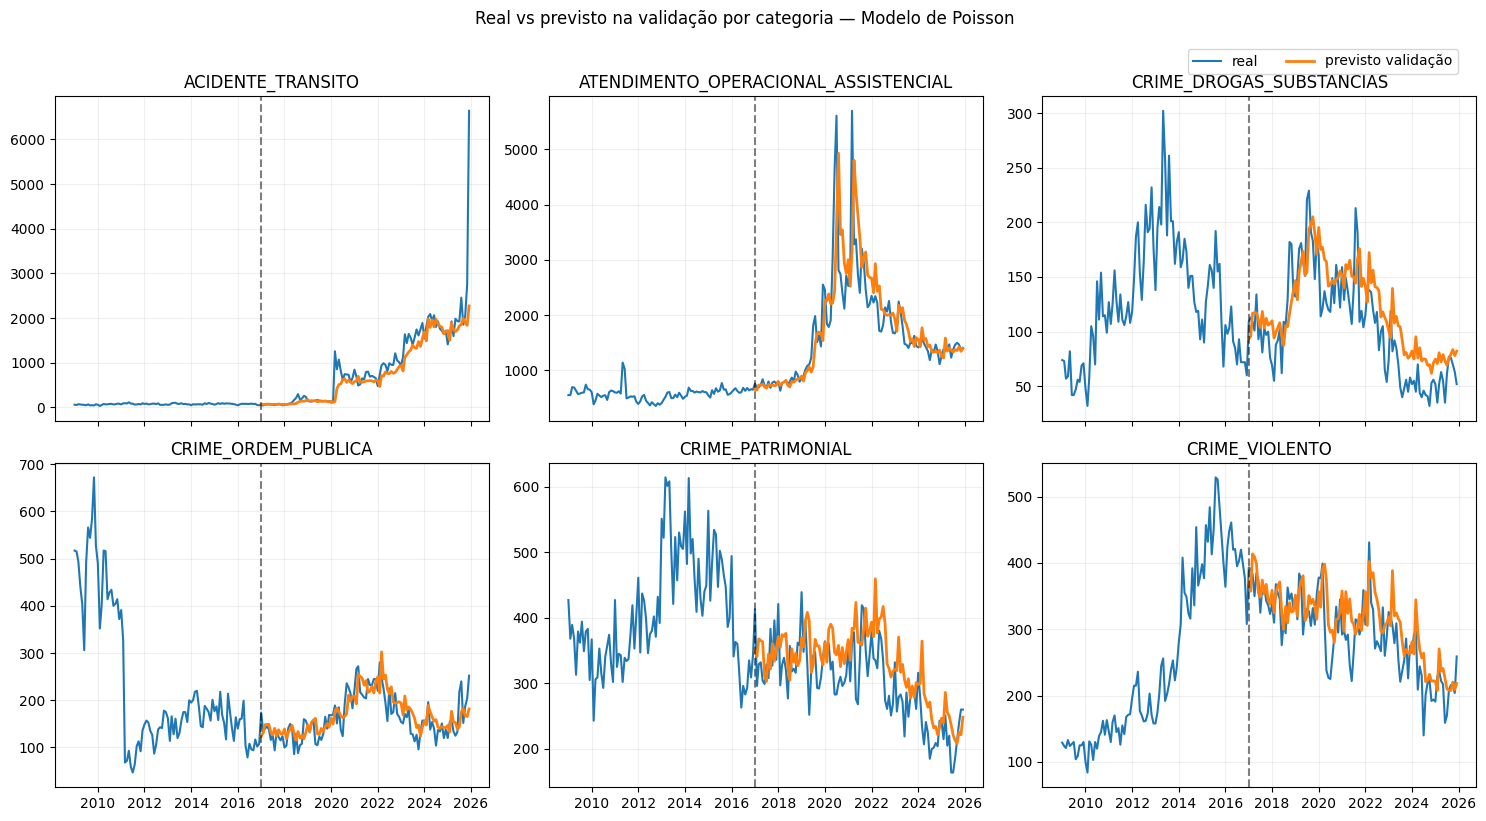

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.ravel()

for ax, categoria in zip(axes, categorias):
    
    tmp_hist = dados_categoria[
        dados_categoria['categoria'] == categoria
    ].copy()
    
    tmp_pred = pred_validacao[
        pred_validacao['categoria'] == categoria
    ].copy()

    ax.plot(
        tmp_hist['data'],
        tmp_hist['qtd_ocorrencias'],
        label='real',
        linewidth=1.5
    )

    ax.plot(
        tmp_pred['data'],
        tmp_pred['predito'],
        label='previsto validação',
        linewidth=2
    )

    ax.axvline(
        DATA_INICIO_VALIDACAO,
        color='black',
        linestyle='--',
        alpha=0.5
    )

    ax.set_title(categoria)
    ax.grid(alpha=0.2)

for ax in axes[len(categorias):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98), ncol=2)

fig.suptitle('Real vs previsto na validação por categoria — Modelo de Poisson', y=1.02)

plt.tight_layout()
plt.show()

In [53]:
comparacao_bairro_mensal = (
    previsoes_poisson
    .groupby(['data', 'bairro'], as_index=False)
    .agg(
        total_real=('y', 'sum'),
        total_previsto=('y_pred', 'sum')
    )
)

comparacao_bairro_mensal.head()

,data,bairro,total_real,total_previsto
0,2017-01-01,abranches,18,9.469815
1,2017-01-01,agua verde,27,35.348283
2,2017-01-01,ahu,2,4.239905
3,2017-01-01,alto boqueirao,58,57.143296
4,2017-01-01,alto da gloria,15,16.108598


In [54]:
avaliacao_bairro = (
    previsoes_poisson
    .groupby('bairro')
    .apply(lambda g: pd.Series(calcular_metricas(g['y'], g['y_pred'])))
    .reset_index()
    .sort_values('WAPE')
)

In [55]:
avaliacao_bairro

,bairro,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
15,boqueirao,6.206544,13.217128,0.269757,0.033444,17394.0,17975.718651
29,cidade industrial,10.134779,25.848336,0.292450,0.043651,26199.0,27342.608136
27,centro,24.993687,80.535678,0.297408,0.063448,63533.0,67564.066253
19,cajuru,6.616643,15.123869,0.308415,0.038516,16219.0,16843.693365
24,capao raso,4.682308,10.009144,0.311851,0.000701,11351.0,11358.954338
...,...,...,...,...,...,...,...
26,caximba,0.775521,1.362687,1.016107,-0.230907,577.0,443.766561
37,hugo lange,0.912415,5.416497,1.079477,-0.366992,639.0,404.492147
2,ahu,0.861048,4.035453,1.162415,-0.126093,560.0,489.387992
42,lamenha pequena,0.145562,0.348487,1.594855,-0.257691,69.0,51.219348


In [56]:
top4_melhores_bairros = (
    avaliacao_bairro
    .sort_values('WAPE', ascending=True)
    .head(4)
    ['bairro']
    .tolist()
)

top4_piores_bairros = (
    avaliacao_bairro
    .sort_values('WAPE', ascending=False)
    .head(4)
    ['bairro']
    .tolist()
)

In [57]:
def plot_real_previsto_bairros(lista_bairros, titulo):
    
    n = len(lista_bairros)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 3.5 * nrows),
        sharex=True
    )
    
    axes = axes.ravel()
    
    for ax, bairro in zip(axes, lista_bairros):
        
        tmp = comparacao_bairro_mensal[
            comparacao_bairro_mensal['bairro'] == bairro
        ].copy()
        
        ax.plot(
            tmp['data'],
            tmp['total_real'],
            label='real',
            linewidth=1.5
        )
        
        ax.plot(
            tmp['data'],
            tmp['total_previsto'],
            label='previsto',
            linewidth=2
        )
        
        ax.set_title(bairro)
        ax.grid(alpha=0.2)
    
    for ax in axes[len(lista_bairros):]:
        ax.axis('off')
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98), ncol=2)
    
    fig.suptitle(titulo, y=1.02)
    plt.tight_layout()
    plt.show()

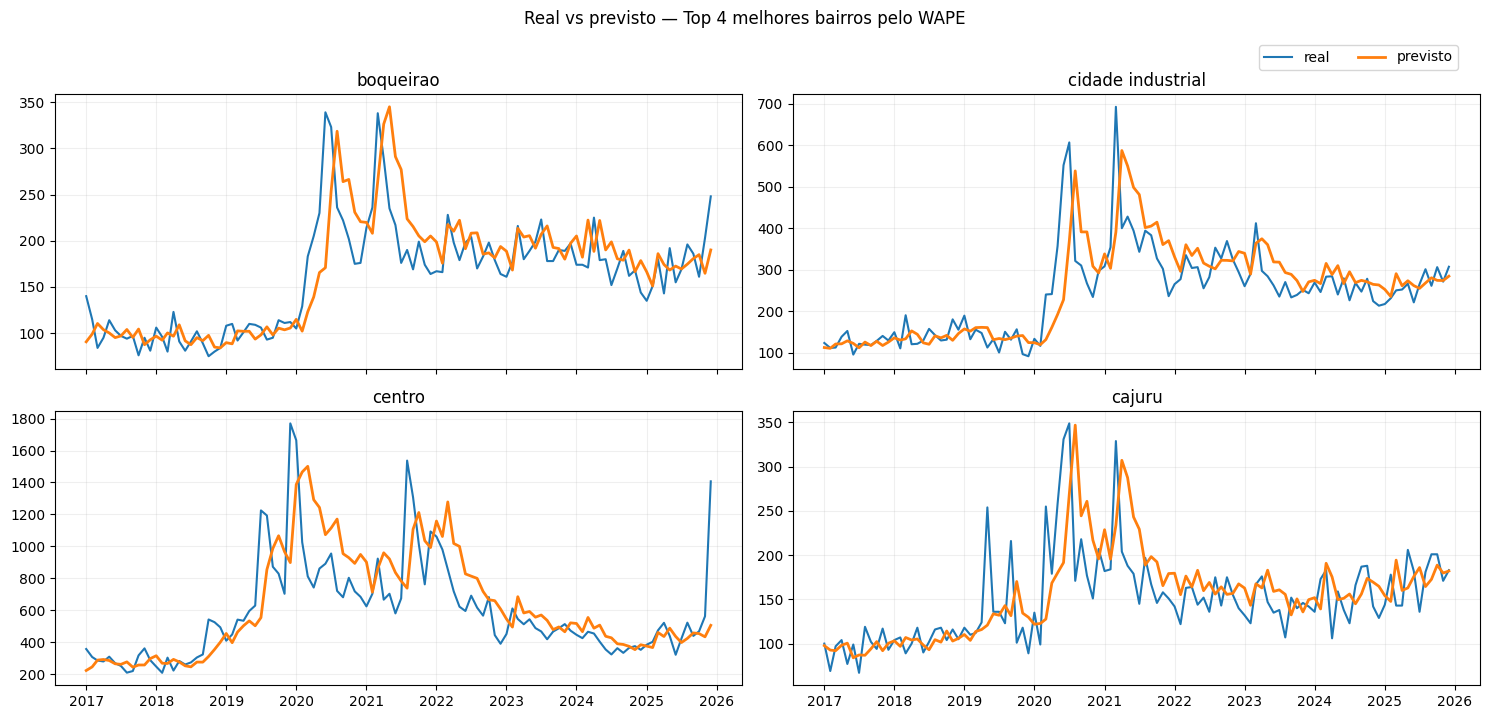

In [58]:
plot_real_previsto_bairros(
    top4_melhores_bairros,
    'Real vs previsto — Top 4 melhores bairros pelo WAPE'
)

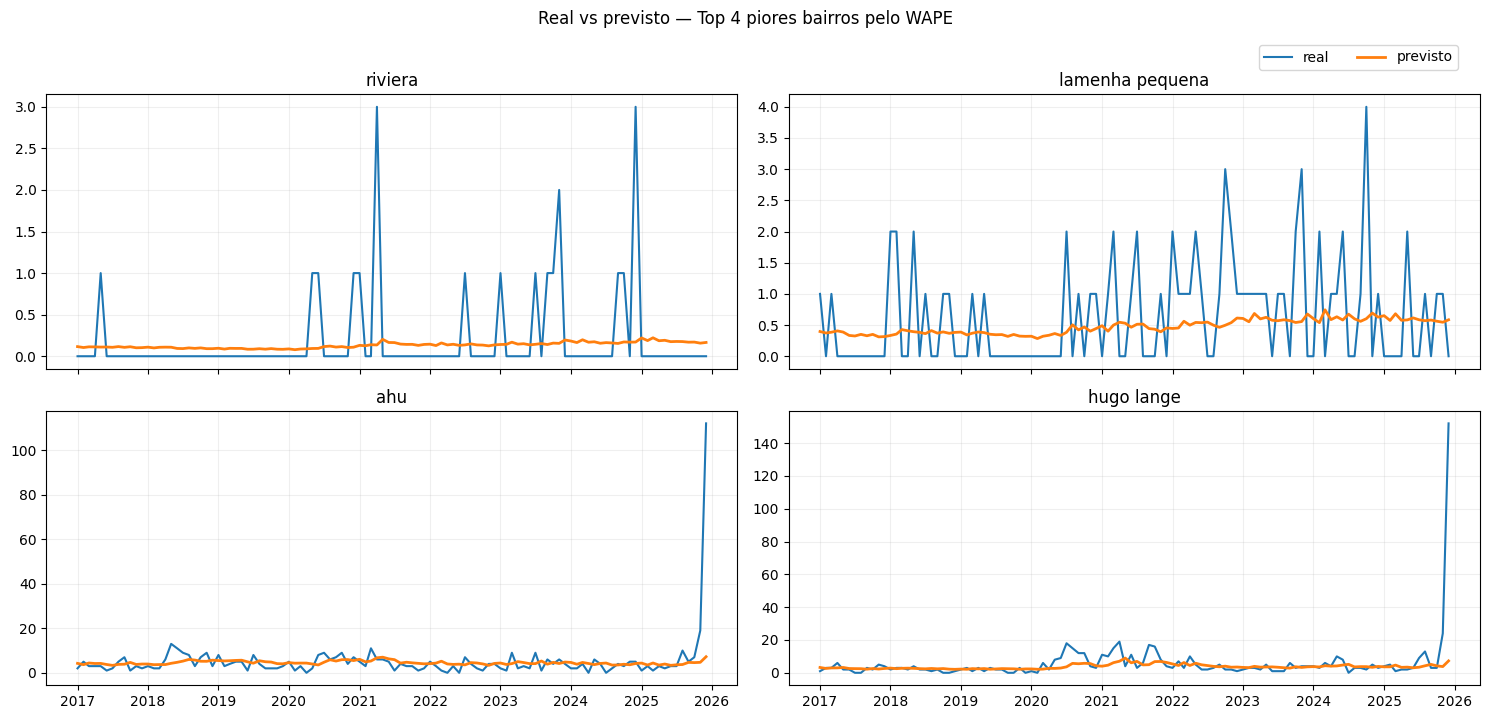

In [59]:
plot_real_previsto_bairros(
    top4_piores_bairros,
    'Real vs previsto — Top 4 piores bairros pelo WAPE'
)

### 3. Modelos de machine learning

Iremos treinar os modelos:

- `PoissonRegressor`;
- `RandomForestRegressor`;
- `ExtraTreesRegressor`;
- `GradientBoostingRegressor`;
- `HistGradientBoostingRegressor`

In [60]:
features_numericas = [
    'log1p_lag_1',
    'log1p_lag_2',
    'log1p_lag_3',
    'log1p_lag_6',
    'log1p_lag_12',
    'log1p_media_3',
    'log1p_media_6',
    'log1p_media_12',
    'IQV',
    'log_pop',
    'tempo',
    'mes'
]

features_categoricas = [
    'bairro',
    'categoria'
]

In [61]:
features = features_numericas + features_categoricas
target = 'y'

In [62]:
preprocessador = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', features_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categoricas)
    ]
)

In [63]:
modelos_ml = {
    'random_forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),

    'extra_trees': ExtraTreesRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),

    'gradient_boosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    'hist_gradient_boosting_poisson': HistGradientBoostingRegressor(
        loss='poisson',
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
}

In [64]:
folds = criar_folds_temporais(
    df_poisson,
    data_col='data',
    inicio_validacao='2017-01-01',
    fim_validacao='2025-12-01',
    janela_validacao_meses=1,
    passo_meses=1
)

In [65]:
resultados_ml = []
predicoes_ml = []

In [66]:
for nome_modelo, modelo_base in modelos_ml.items():
    
    print(f'Rodando modelo: {nome_modelo}')
    
    for i, (train_idx, val_idx) in enumerate(folds, start=1):
        
        train = df_poisson.loc[train_idx].copy()
        val = df_poisson.loc[val_idx].copy()
        
        if train.empty or val.empty:
            continue
        
        X_train = train[features]
        y_train = train[target]
        
        X_val = val[features]
        y_val = val[target]
        
        pipeline = Pipeline(
            steps=[
                ('preprocessador', preprocessador),
                ('modelo', modelo_base)
            ]
        )
        
        pipeline.fit(X_train, y_train)
        
        y_pred = pipeline.predict(X_val)

        y_pred = np.clip(y_pred, 0, None)
        
        metricas = calcular_metricas(y_val, y_pred)
        
        resultados_ml.append({
            'modelo': nome_modelo,
            'fold': i,
            'data_validacao': val['data'].min(),
            'n_treino': len(train),
            'n_validacao': len(val),
            **metricas
        })
        
        val_pred = val.copy()
        val_pred['modelo'] = nome_modelo
        val_pred['fold'] = i
        val_pred['y_pred'] = y_pred
        
        predicoes_ml.append(val_pred)

resultados_ml = pd.DataFrame(resultados_ml)
predicoes_ml = pd.concat(predicoes_ml, ignore_index=True)

Rodando modelo: random_forest
Rodando modelo: extra_trees
Rodando modelo: gradient_boosting
Rodando modelo: hist_gradient_boosting_poisson


In [67]:
comparacao_modelos = (
    resultados_ml
    .groupby('modelo')
    .agg(
        MAE=('MAE', 'mean'),
        RMSE=('RMSE', 'mean'),
        WAPE=('WAPE', 'mean'),
        BIAS=('BIAS', 'mean'),
        TOTAL_REAL=('TOTAL_REAL', 'sum'),
        TOTAL_PREVISTO=('TOTAL_PREVISTO', 'sum')
    )
    .reset_index()
    .sort_values('WAPE')
)

comparacao_modelos

,modelo,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
0,extra_trees,2.659786,8.391909,0.379656,0.004524,399123,398170.615012
1,gradient_boosting,2.688086,8.700586,0.386184,0.014380,399123,401894.383822
2,hist_gradient_boosting_poisson,2.724402,9.016344,0.389312,0.010473,399123,400407.888096
3,random_forest,2.718501,8.453257,0.389386,0.029621,399123,408427.059997


In [68]:
melhor_modelo_ml = comparacao_modelos.iloc[0]['modelo']

print(f'Melhor modelo na validação temporal: {melhor_modelo_ml}')

Melhor modelo na validação temporal: extra_trees


In [69]:
pred_melhor_ml = predicoes_ml[
    predicoes_ml['modelo'] == melhor_modelo_ml
].copy()

In [70]:
avaliacao_categoria_ml = (
    pred_melhor_ml
    .groupby('categoria')
    .apply(lambda g: pd.Series(calcular_metricas(g['y'], g['y_pred'])))
    .reset_index()
    .sort_values('WAPE')
)

avaliacao_categoria_ml

,categoria,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
0,ACIDENTE_TRANSITO,4.040575,14.656082,0.326438,-0.088246,100260.0,91412.411426
1,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,7.394507,25.923461,0.327049,0.024861,183139.0,187692.084182
4,CRIME_PATRIMONIAL,1.683095,2.739148,0.420281,0.036561,32438.0,33623.965369
5,CRIME_VIOLENTO,1.660045,2.693560,0.424002,0.051108,31713.0,33333.780831
3,CRIME_ORDEM_PUBLICA,1.192990,1.973808,0.549140,0.019253,17597.0,17935.801904
6,OUTROS,1.740942,5.414305,0.621628,-0.037227,22685.0,21840.496924
2,CRIME_DROGAS_SUBSTANCIAS,0.906350,2.393886,0.650203,0.092204,11291.0,12332.074376


In [71]:
avaliacao_bairro_categoria_ml = (
    pred_melhor_ml
    .groupby(['bairro', 'categoria'])
    .apply(lambda g: pd.Series(calcular_metricas(g['y'], g['y_pred'])))
    .reset_index()
    .sort_values('WAPE')
)

avaliacao_bairro_categoria_ml

,bairro,categoria,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
194,centro,CRIME_VIOLENTO,8.066303,10.272279,0.178553,0.030406,4879.0,5027.352395
203,cidade industrial,ACIDENTE_TRANSITO,12.373679,18.823277,0.179257,-0.033265,7455.0,7207.006619
193,centro,CRIME_PATRIMONIAL,8.275277,9.748632,0.191746,0.012461,4661.0,4719.079193
518,xaxim,ACIDENTE_TRANSITO,6.194951,9.127737,0.202682,-0.048015,3301.0,3142.501909
105,boqueirao,ACIDENTE_TRANSITO,8.001979,12.961845,0.206799,-0.065178,4179.0,3906.622654
...,...,...,...,...,...,...,...,...
296,lamenha pequena,CRIME_DROGAS_SUBSTANCIAS,0.023144,0.025387,NaN,NaN,0.0,2.499514
380,riviera,CRIME_DROGAS_SUBSTANCIAS,0.010035,0.011356,NaN,NaN,0.0,1.083764
382,riviera,CRIME_PATRIMONIAL,0.014887,0.016149,NaN,NaN,0.0,1.607806
383,riviera,CRIME_VIOLENTO,0.017584,0.019078,NaN,NaN,0.0,1.899116


In [72]:
DATA_INICIO_VALIDACAO = pd.to_datetime('2017-01-01')

In [73]:
dados_categoria = (
    df_mensal
    .groupby(['data', 'categoria'], as_index=False)
    .agg(qtd_ocorrencias=('y', 'sum'))
)

pred_categoria_ml = (
    pred_melhor_ml
    .groupby(['data', 'categoria'], as_index=False)
    .agg(predito=('y_pred', 'sum'))
)

categorias = sorted(pred_categoria_ml['categoria'].unique())

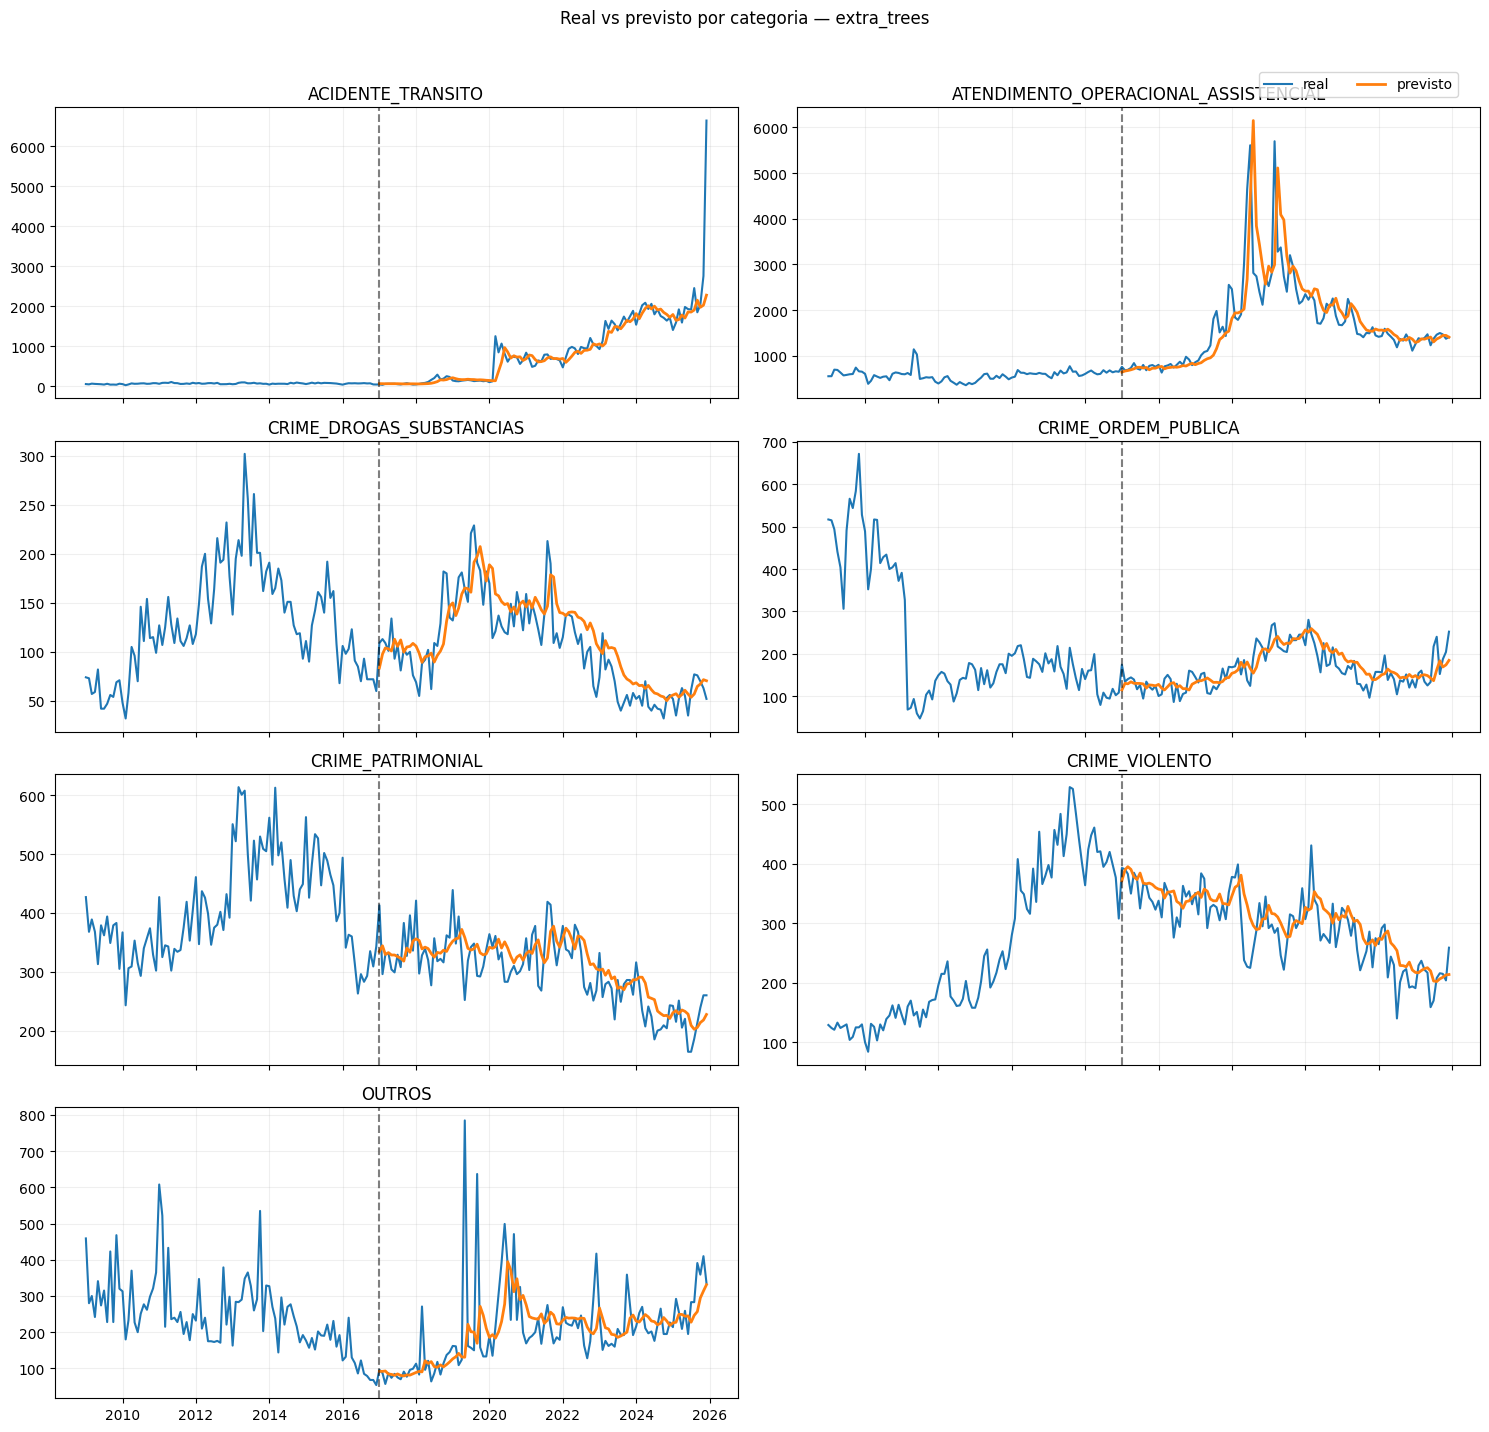

In [74]:
fig, axes = plt.subplots(4, 2, figsize=(15, 14), sharex=True)
axes = axes.ravel()

for ax, categoria in zip(axes, categorias):
    
    tmp_hist = dados_categoria[
        dados_categoria['categoria'] == categoria
    ].copy()
    
    tmp_pred = pred_categoria_ml[
        pred_categoria_ml['categoria'] == categoria
    ].copy()
    
    ax.plot(
        tmp_hist['data'],
        tmp_hist['qtd_ocorrencias'],
        label='real',
        linewidth=1.5
    )
    
    ax.plot(
        tmp_pred['data'],
        tmp_pred['predito'],
        label='previsto',
        linewidth=2
    )
    
    ax.axvline(
        DATA_INICIO_VALIDACAO,
        color='black',
        linestyle='--',
        alpha=0.5
    )
    
    ax.set_title(categoria)
    ax.grid(alpha=0.2)

for ax in axes[len(categorias):]:
    ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98), ncol=2)

fig.suptitle(f'Real vs previsto por categoria — {melhor_modelo_ml}', y=1.02)

plt.tight_layout()
plt.show()

O melhor modelo, extra_trees, apresentou desempenho superior à melhor baseline, embora a diferença não tenha sido muito expressiva. Esse resultado indica que, no momento, o principal fator limitante não parece ser a escolha do algoritmo, mas sim a qualidade, a quantidade e a capacidade explicativa das variáveis disponíveis.

Considerando que as categorias de ocorrências apresentam escalas bastante distintas, será adotada uma estratégia de modelagem separada por tipo de ocorrência. Dessa forma, serão desenvolvidos seis modelos específicos:

- Um modelo para `ACIDENTE_TRANSITO`;
- Um modelo para `ATENDIMENTO_OPERACIONAL_ASSISTENCIAL`;
- Um modelo para `CRIME_PATRIMONIAL`;
- Um modelo para `CRIME_VIOLENTO`;
- Um modelo para `CRIME_ORDEM_PUBLICA`;
- Um modelo para `CRIME_DROGAS_SUBSTANCIA`.

Além disso, a categoria `OUTROS`, por ser naturalmente heterogênea, reúne ocorrências com comportamentos muito diferentes entre si. Essa característica tende a dificultar a identificação de padrões consistentes e, consequentemente, pode prejudicar o desempenho geral dos modelos. Por esse motivo, essa categoria será tratada separadamente ou excluída das próximas etapas de modelagem, a depender dos objetivos da análise.

### 4. Modelos separados por categoria

In [75]:
categorias_modelar = [
    'ACIDENTE_TRANSITO',
    'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL',
    'CRIME_PATRIMONIAL',
    'CRIME_VIOLENTO',
    'CRIME_ORDEM_PUBLICA',
    'CRIME_DROGAS_SUBSTANCIAS'
]

In [76]:
df_cat_modelos = df_poisson[
    df_poisson['categoria'].isin(categorias_modelar)
].copy()

Iremos acrescentar um fator de sazonalidade cíclica por mês

In [77]:
for k in [1, 2]:
    df_cat_modelos[f'mes_sin_{k}'] = np.sin(2 * np.pi * k * df_cat_modelos['mes'] / 12)
    df_cat_modelos[f'mes_cos_{k}'] = np.cos(2 * np.pi * k * df_cat_modelos['mes'] / 12)

In [78]:
features_numericas_cat = [
    'log1p_lag_1',
    'log1p_lag_2',
    'log1p_lag_3',
    'log1p_lag_6',
    'log1p_lag_12',
    'log1p_media_3',
    'log1p_media_6',
    'log1p_media_12',
    'IQV',
    'log_pop',
    'tempo',
    'mes_sin_1',
    'mes_cos_1',
    'mes_sin_2',
    'mes_cos_2'
]

In [79]:
features_categoricas_cat = [
    'bairro'
]

In [80]:
features_cat = features_numericas_cat + features_categoricas_cat
target = 'y'

In [81]:
preprocessador_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_numericas_cat),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categoricas_cat)
    ]
)

In [82]:
preprocessador_arvore = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', features_numericas_cat),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categoricas_cat)
    ]
)

In [83]:
modelos_contagem = {
    'poisson_regressor': Pipeline(
        steps=[
            ('preprocessador', preprocessador_linear),
            ('modelo', PoissonRegressor(
                alpha=0.1,
                max_iter=2000
            ))
        ]
    ),

    'random_forest': Pipeline(
        steps=[
            ('preprocessador', preprocessador_arvore),
            ('modelo', RandomForestRegressor(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

    'tweedie_regressor': Pipeline(
        steps=[
            ('preprocessador', preprocessador_linear),
            ('modelo', TweedieRegressor(
                power=1.5,
                link='log',
                alpha=0.1,
                max_iter=2000
            ))
        ]
    ),

    'xgboost_poisson': Pipeline(
        steps=[
            ('preprocessador', preprocessador_arvore),
            ('modelo', XGBRegressor(
                objective='count:poisson',
                n_estimators=500,
                learning_rate=0.03,
                max_depth=4,
                min_child_weight=10,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.0,
                tree_method='hist',
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

    'hist_gradient_boosting_poisson': Pipeline(
        steps=[
            ('preprocessador', preprocessador_arvore),
            ('modelo', HistGradientBoostingRegressor(
                loss='poisson',
                max_iter=500,
                learning_rate=0.03,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                l2_regularization=0.1,
                random_state=42
            ))
        ]
    )
}

In [84]:
resultados_modelos_categoria = []
predicoes_modelos_categoria = []

In [85]:
resultados_modelos_categoria = []
predicoes_modelos_categoria = []

for categoria in categorias_modelar:
    dados_categoria = df_cat_modelos[
        df_cat_modelos['categoria'] == categoria
    ].copy()

    folds_categoria = criar_folds_temporais(
        dados_categoria,
        data_col='data',
        inicio_validacao='2017-01-01',
        fim_validacao='2025-12-01',
        janela_validacao_meses=1,
        passo_meses=1
    )

    for nome_modelo, pipeline_base in modelos_contagem.items():

        print(f'Categoria: {categoria} | Modelo: {nome_modelo}')

        for i, (train_idx, val_idx) in enumerate(folds_categoria, start=1):

            train = dados_categoria.loc[train_idx].copy()
            val = dados_categoria.loc[val_idx].copy()

            if train.empty or val.empty:
                continue

            X_train = train[features_cat]
            y_train = train[target]

            X_val = val[features_cat]
            y_val = val[target]

            pipeline = clone(pipeline_base)
            pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_val)
            y_pred = np.clip(y_pred, 0, None)

            metricas = calcular_metricas(y_val, y_pred)

            resultados_modelos_categoria.append({
                'categoria': categoria,
                'modelo': nome_modelo,
                'fold': i,
                'data_validacao': val['data'].min(),
                'n_treino': len(train),
                'n_validacao': len(val),
                **metricas
            })

            val_pred = val.copy()
            val_pred['modelo'] = nome_modelo
            val_pred['fold'] = i
            val_pred['y_pred'] = y_pred

            predicoes_modelos_categoria.append(val_pred)

Categoria: ACIDENTE_TRANSITO | Modelo: poisson_regressor
Categoria: ACIDENTE_TRANSITO | Modelo: random_forest
Categoria: ACIDENTE_TRANSITO | Modelo: tweedie_regressor
Categoria: ACIDENTE_TRANSITO | Modelo: xgboost_poisson
Categoria: ACIDENTE_TRANSITO | Modelo: hist_gradient_boosting_poisson
Categoria: ATENDIMENTO_OPERACIONAL_ASSISTENCIAL | Modelo: poisson_regressor
Categoria: ATENDIMENTO_OPERACIONAL_ASSISTENCIAL | Modelo: random_forest
Categoria: ATENDIMENTO_OPERACIONAL_ASSISTENCIAL | Modelo: tweedie_regressor
Categoria: ATENDIMENTO_OPERACIONAL_ASSISTENCIAL | Modelo: xgboost_poisson
Categoria: ATENDIMENTO_OPERACIONAL_ASSISTENCIAL | Modelo: hist_gradient_boosting_poisson
Categoria: CRIME_PATRIMONIAL | Modelo: poisson_regressor
Categoria: CRIME_PATRIMONIAL | Modelo: random_forest
Categoria: CRIME_PATRIMONIAL | Modelo: tweedie_regressor
Categoria: CRIME_PATRIMONIAL | Modelo: xgboost_poisson
Categoria: CRIME_PATRIMONIAL | Modelo: hist_gradient_boosting_poisson
Categoria: CRIME_VIOLENTO | M

In [86]:
resultados_modelos_categoria = pd.DataFrame(resultados_modelos_categoria)
predicoes_modelos_categoria = pd.concat(predicoes_modelos_categoria, ignore_index=True)

In [87]:
comparacao_modelos_categoria = (
    resultados_modelos_categoria
    .groupby(['categoria', 'modelo'], as_index=False)
    .agg(
        MAE=('MAE', 'mean'),
        RMSE=('RMSE', 'mean'),
        WAPE=('WAPE', 'mean'),
        BIAS=('BIAS', 'mean'),
        TOTAL_REAL=('TOTAL_REAL', 'sum'),
        TOTAL_PREVISTO=('TOTAL_PREVISTO', 'sum')
    )
    .sort_values(['categoria', 'WAPE'])
)

In [88]:
comparacao_modelos_categoria

,categoria,modelo,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
4,ACIDENTE_TRANSITO,xgboost_poisson,4.105537,6.928869,0.460438,0.003485,100260,94780.830898
0,ACIDENTE_TRANSITO,hist_gradient_boosting_poisson,4.205990,7.134712,0.469938,-0.003492,100260,94586.513134
1,ACIDENTE_TRANSITO,poisson_regressor,4.394038,7.617717,0.491057,0.035190,100260,99172.026358
2,ACIDENTE_TRANSITO,random_forest,4.374283,7.168280,0.501345,0.078046,100260,98575.346412
3,ACIDENTE_TRANSITO,tweedie_regressor,5.613615,11.004038,0.584901,0.169016,100260,113533.345700
9,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,xgboost_poisson,7.096757,16.029910,0.295729,0.013871,183139,185943.138733
5,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,hist_gradient_boosting_poisson,7.455733,17.909010,0.307347,0.021243,183139,188281.971699
6,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,poisson_regressor,7.650677,18.556861,0.314649,0.070328,183139,194456.611630
7,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,random_forest,7.601155,18.029142,0.314820,0.047167,183139,192701.111780
8,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,tweedie_regressor,8.395645,21.306968,0.339535,0.110895,183139,202968.559928


In [89]:
melhor_modelo_por_categoria = (
    comparacao_modelos_categoria
    .sort_values(['categoria', 'WAPE'])
    .groupby('categoria', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

In [90]:
melhor_modelo_por_categoria

,categoria,modelo,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
0,ACIDENTE_TRANSITO,xgboost_poisson,4.105537,6.928869,0.460438,0.003485,100260,94780.830898
1,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,xgboost_poisson,7.096757,16.029910,0.295729,0.013871,183139,185943.138733
2,CRIME_DROGAS_SUBSTANCIAS,xgboost_poisson,0.858535,1.883001,0.682292,0.045847,11291,11399.628258
3,CRIME_ORDEM_PUBLICA,xgboost_poisson,1.192355,1.929954,0.566288,0.023315,17597,17683.171715
4,CRIME_PATRIMONIAL,xgboost_poisson,1.653303,2.639129,0.420123,0.010981,32438,32489.036423
5,CRIME_VIOLENTO,xgboost_poisson,1.633853,2.611356,0.425608,0.009082,31713,31684.135422


In [91]:
melhor_baseline_por_categoria = (
    resumo_categoria[
        resumo_categoria['categoria'].isin(categorias_modelar)
    ]
    .sort_values(['categoria', 'WAPE'])
    .groupby('categoria', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

In [92]:
comparacao_final_categoria = (
    melhor_modelo_por_categoria
    .merge(
        melhor_baseline_por_categoria,
        on='categoria',
        suffixes=('_modelo', '_baseline')
    )
)

In [93]:
comparacao_final_categoria['ganho_WAPE_abs'] = (
    comparacao_final_categoria['WAPE_baseline']
    - comparacao_final_categoria['WAPE_modelo']
)

comparacao_final_categoria['ganho_WAPE_pct'] = (
    comparacao_final_categoria['ganho_WAPE_abs']
    / comparacao_final_categoria['WAPE_baseline']
)

comparacao_final_categoria['ganho_MAE_abs'] = (
    comparacao_final_categoria['MAE_baseline']
    - comparacao_final_categoria['MAE_modelo']
)

comparacao_final_categoria[
    [
        'categoria',
        'modelo',
        'baseline',
        'MAE_modelo',
        'MAE_baseline',
        'WAPE_modelo',
        'WAPE_baseline',
        'ganho_WAPE_abs',
        'ganho_WAPE_pct',
        'BIAS_modelo',
        'BIAS_baseline'
    ]
].sort_values('WAPE_modelo')

,categoria,modelo,baseline,MAE_modelo,MAE_baseline,WAPE_modelo,WAPE_baseline,ganho_WAPE_abs,ganho_WAPE_pct,BIAS_modelo,BIAS_baseline
1,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,xgboost_poisson,baseline_media_6m,7.096757,7.427058,0.295729,0.304335,0.008606,0.028277,0.013871,0.007663
4,CRIME_PATRIMONIAL,xgboost_poisson,baseline_media_12m,1.653303,1.689311,0.420123,0.430577,0.010453,0.024278,0.010981,0.038596
5,CRIME_VIOLENTO,xgboost_poisson,baseline_media_12m,1.633853,1.640463,0.425608,0.431120,0.005511,0.012784,0.009082,0.056002
0,ACIDENTE_TRANSITO,xgboost_poisson,baseline_media_6m,4.105537,4.156728,0.460438,0.465975,0.005536,0.011881,0.003485,-0.043118
3,CRIME_ORDEM_PUBLICA,xgboost_poisson,baseline_media_12m,1.192355,1.194743,0.566288,0.569263,0.002975,0.005227,0.023315,0.003967
2,CRIME_DROGAS_SUBSTANCIAS,xgboost_poisson,baseline_media_6m,0.858535,0.872016,0.682292,0.696000,0.013707,0.019695,0.045847,0.055031


In [94]:
pred_melhores_categoria = predicoes_modelos_categoria.merge(
    melhor_modelo_por_categoria[['categoria', 'modelo']],
    on=['categoria', 'modelo'],
    how='inner'
)

In [95]:
avaliacao_melhores_categoria = (
    pred_melhores_categoria
    .groupby('categoria')
    .apply(lambda g: pd.Series(calcular_metricas(g['y'], g['y_pred'])))
    .reset_index()
    .sort_values('WAPE')
)

avaliacao_melhores_categoria

,categoria,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
1,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,7.096757,24.709480,0.313880,0.015312,183139.0,185943.138602
0,ACIDENTE_TRANSITO,4.105537,14.455632,0.331686,-0.054650,100260.0,94780.830590
4,CRIME_PATRIMONIAL,1.653303,2.719105,0.412841,0.001573,32438.0,32489.036381
5,CRIME_VIOLENTO,1.633853,2.692313,0.417312,-0.000910,31713.0,31684.135574
3,CRIME_ORDEM_PUBLICA,1.192355,1.993756,0.548848,0.004897,17597.0,17683.171782
2,CRIME_DROGAS_SUBSTANCIAS,0.858535,2.305628,0.615900,0.009621,11291.0,11399.628166


In [96]:
modelos_finais_por_categoria = {}

In [97]:
for _, linha in melhor_modelo_por_categoria.iterrows():

    categoria = linha['categoria']
    nome_modelo = linha['modelo']

    dados_categoria = df_cat_modelos[
        df_cat_modelos['categoria'] == categoria
    ].copy()

    pipeline_final = clone(modelos_contagem[nome_modelo])

    pipeline_final.fit(
        dados_categoria[features_cat],
        dados_categoria[target]
    )

    modelos_finais_por_categoria[categoria] = pipeline_final

modelos_finais_por_categoria.keys()

dict_keys(['ACIDENTE_TRANSITO', 'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL', 'CRIME_DROGAS_SUBSTANCIAS', 'CRIME_ORDEM_PUBLICA', 'CRIME_PATRIMONIAL', 'CRIME_VIOLENTO'])

In [98]:
dados_reais_categoria = (
    df_cat_modelos
    .groupby(['data', 'categoria'], as_index=False)
    .agg(real=('y', 'sum'))
)

pred_categoria = (
    pred_melhores_categoria
    .groupby(['data', 'categoria'], as_index=False)
    .agg(previsto=('y_pred', 'sum'))
)

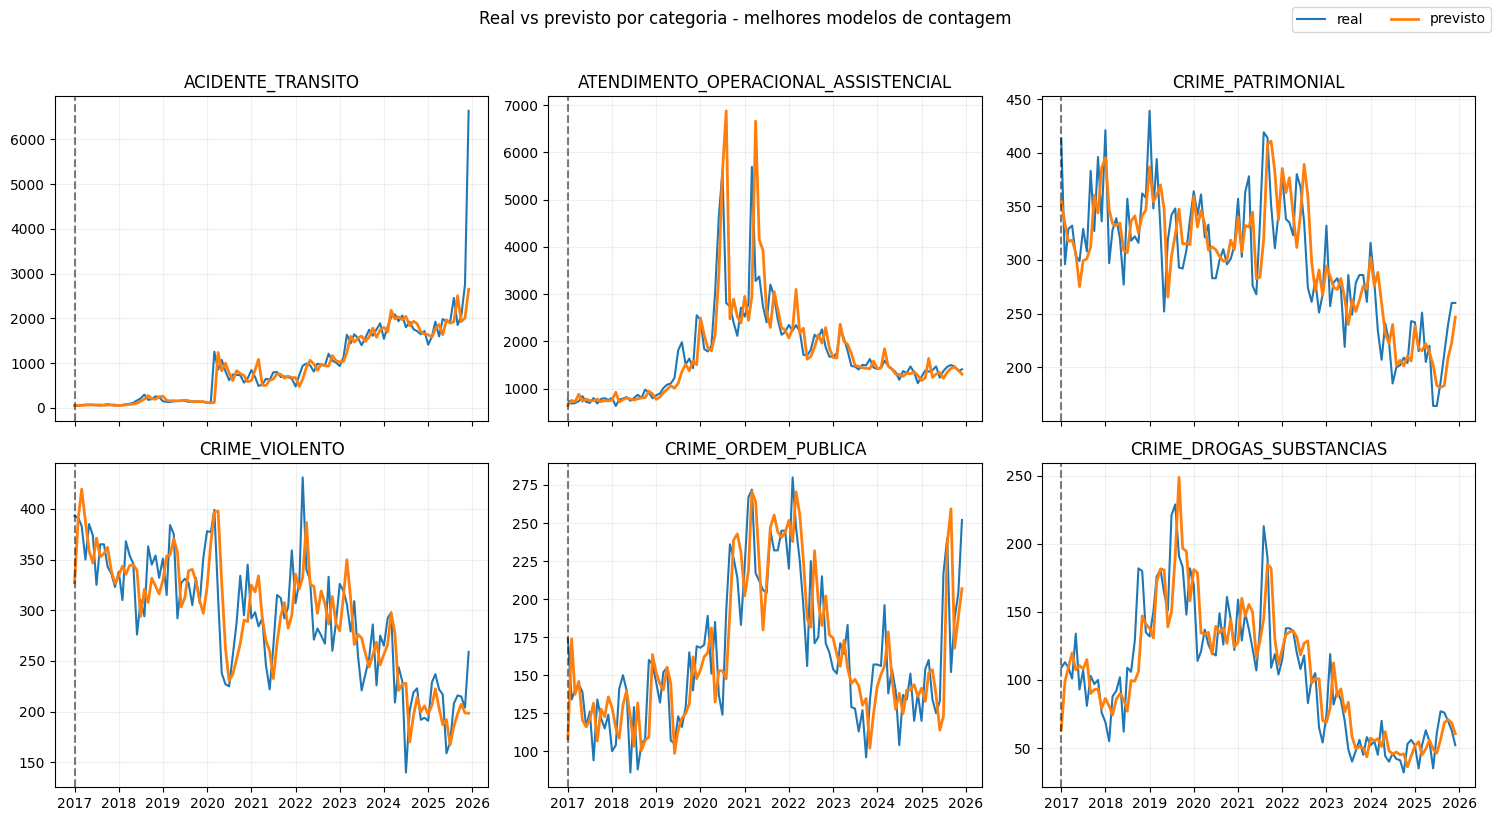

In [99]:
plot_categoria = dados_reais_categoria.merge(
    pred_categoria,
    on=['data', 'categoria'],
    how='inner'
)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.ravel()

for ax, categoria in zip(axes, categorias_modelar):

    tmp = plot_categoria[
        plot_categoria['categoria'] == categoria
    ].copy()

    ax.plot(tmp['data'], tmp['real'], label='real', linewidth=1.5)
    ax.plot(tmp['data'], tmp['previsto'], label='previsto', linewidth=2)

    ax.axvline(
        pd.to_datetime('2017-01-01'),
        color='black',
        linestyle='--',
        alpha=0.5
    )

    ax.set_title(categoria)
    ax.grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=2)

fig.suptitle('Real vs previsto por categoria - melhores modelos de contagem', y=1.02)
plt.tight_layout()
plt.show()

In [100]:
comparacao_bairro_mensal_individual = (
    pred_melhores_categoria
    .groupby(['data', 'bairro'], as_index=False)
    .agg(
        total_real=('y', 'sum'),
        total_previsto=('y_pred', 'sum')
    )
)

comparacao_bairro_mensal_individual.head()

,data,bairro,total_real,total_previsto
0,2017-01-01,abranches,17,8.714458
1,2017-01-01,agua verde,26,30.213242
2,2017-01-01,ahu,2,3.158245
3,2017-01-01,alto boqueirao,56,47.136072
4,2017-01-01,alto da gloria,15,15.203415


In [101]:
avaliacao_bairro_individual = (
    pred_melhores_categoria
    .groupby('bairro')
    .apply(lambda g: pd.Series(calcular_metricas(g['y'], g['y_pred'])))
    .reset_index()
    .sort_values('WAPE')
)

avaliacao_bairro_individual

,bairro,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
27,centro,22.759408,75.551630,0.237528,-0.064002,62090.0,58116.130988
15,boqueirao,6.092250,13.457147,0.241454,-0.004819,16350.0,16271.213936
29,cidade industrial,9.495093,30.674405,0.249344,-0.013702,24676.0,24337.900382
19,cajuru,5.966010,15.083009,0.262331,0.010821,14737.0,14896.469636
24,capao raso,4.710975,10.473044,0.281304,-0.045454,10852.0,10358.737402
...,...,...,...,...,...,...,...
40,jardim social,0.751878,1.328832,0.996354,0.245240,489.0,608.922132
37,hugo lange,0.979744,5.455893,1.025645,-0.032390,619.0,598.950588
2,ahu,0.903598,3.827480,1.115298,0.115096,525.0,585.425293
42,lamenha pequena,0.203108,0.377580,2.024830,0.720062,65.0,111.804057


In [102]:
top4_melhores_bairros_individual = (
    avaliacao_bairro_individual
    .sort_values('WAPE', ascending=True)
    .head(4)
    ['bairro']
    .tolist()
)

In [103]:
top4_piores_bairros_individual = (
    avaliacao_bairro_individual
    .sort_values('WAPE', ascending=False)
    .head(4)
    ['bairro']
    .tolist()
)

In [106]:
def plot_real_previsto_bairros_individual(lista_bairros, titulo):

    n = len(lista_bairros)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(15, 3.5 * nrows),
        sharex=True
    )

    axes = axes.ravel()

    for ax, bairro in zip(axes, lista_bairros):

        tmp = comparacao_bairro_mensal_individual[
            comparacao_bairro_mensal_individual['bairro'] == bairro
        ].copy()

        ax.plot(
            tmp['data'],
            tmp['total_real'],
            label='real',
            linewidth=1.5
        )

        ax.plot(
            tmp['data'],
            tmp['total_previsto'],
            label='previsto',
            linewidth=2
        )

        ax.axvline(
            pd.to_datetime('2017-01-01'),
            color='black',
            linestyle='--',
            alpha=0.5
        )

        ax.set_title(bairro)
        ax.grid(alpha=0.2)

    for ax in axes[len(lista_bairros):]:
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', ncol=2)

    fig.suptitle(titulo, y=1.02)
    plt.tight_layout()
    plt.show()

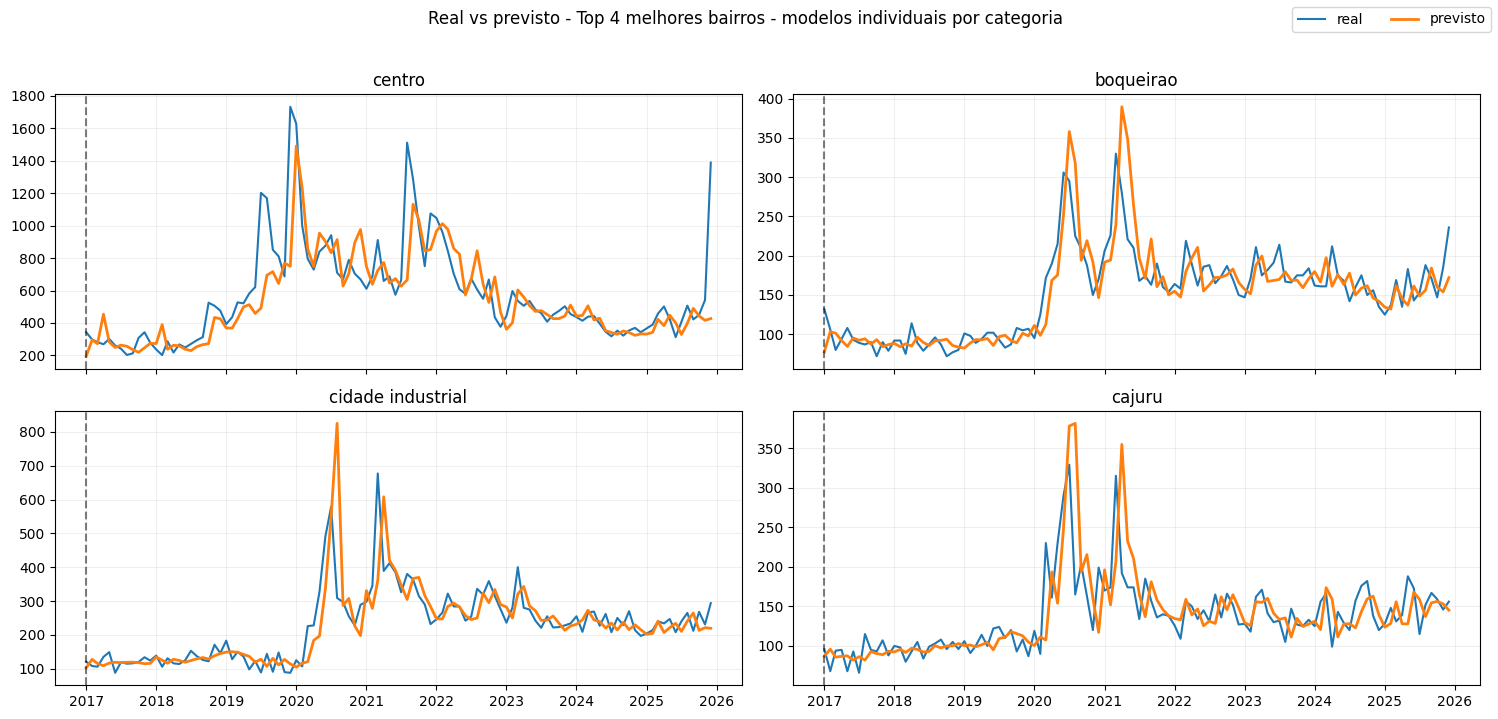

In [107]:
plot_real_previsto_bairros_individual(
    top4_melhores_bairros_individual,
    'Real vs previsto - Top 4 melhores bairros - modelos individuais por categoria'
)

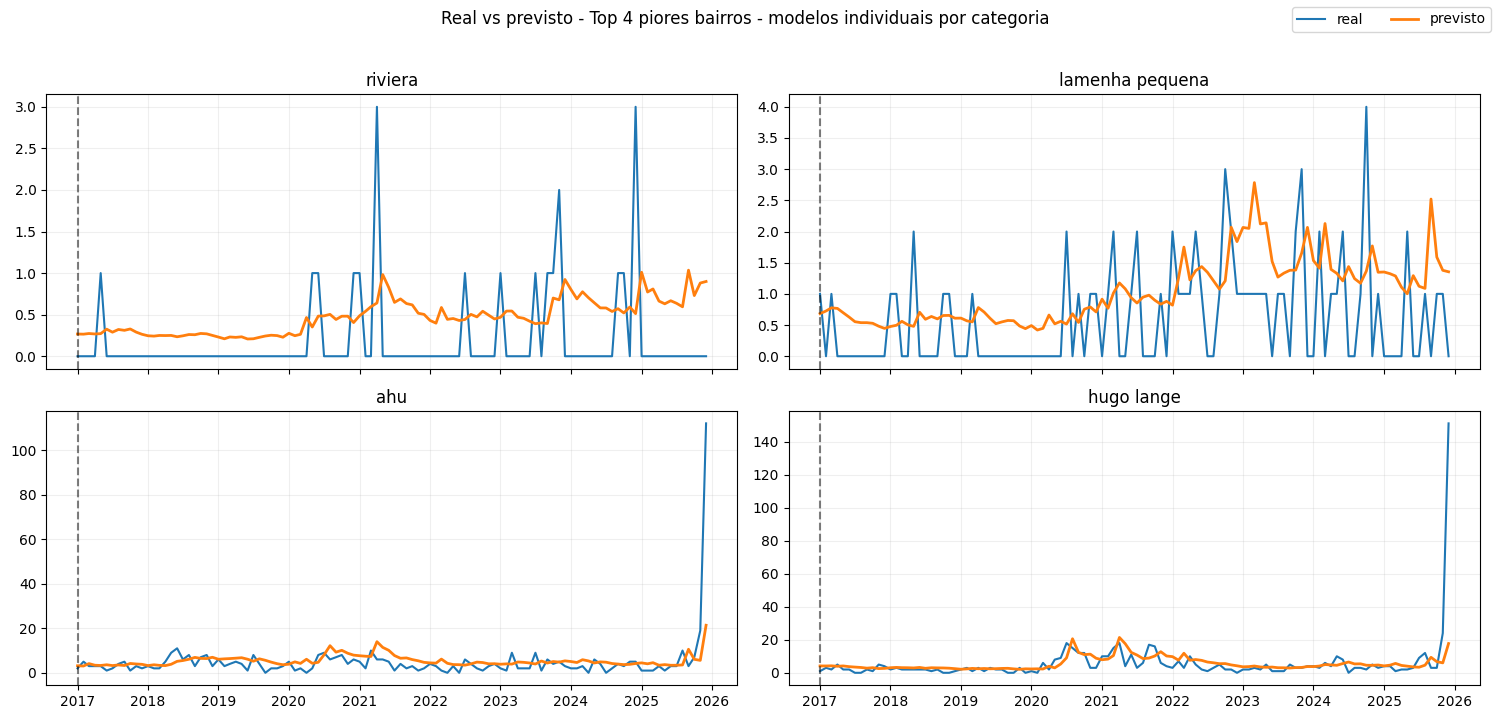

In [108]:
plot_real_previsto_bairros_individual(
    top4_piores_bairros_individual,
    'Real vs previsto - Top 4 piores bairros - modelos individuais por categoria'
)

### 4. Otimizacao de hiperparametros do XGBoost Poisson por categoria

Para aprimorar o desempenho dos modelos de previsão, será realizada uma etapa de otimização de hiperparâmetros para o melhor modelo, o XGBoost, utilizando a função objetivo count:poisson. Essa escolha é adequada ao problema, pois a variável-alvo repreenta uma contagem de ocorrências, isto é, valores inteiros não negativos associados ao número de eventos registrados em determinado período.

A otimização será feita por meio de uma busca aleatória de hiperparâmetros, utilizando ParameterSampler. Em vez de testar todas as combinações possíveis, o procedimento seleciona aleatoriamente um conjunto limitado de configurações dentro dos valores definidos. Nesse caso, serão avaliadas 20 combinações distintas de hiperparâmetros, com random_state = 42, garantindo reprodutibilidade.

Foram considerados hiperparâmetros relacionados à complexidades das árvores, à taxa de aprendizado, à regularização e à amostragem dos dados:

- `n_estimators`: controla o número de árvore do modelo;
- `learning_rate`: define o ritmo de aprendizado;
- `max_depth`: limita a profundidade das árvores;
- `min_child_weight`: controle de divisões em nós com poucos dados;
- `reg_alpha`, `reg_lambda` e `gamma` são parâmetros de regularização;
- `subsample` e `colsample_bytree` são responsáveis por controlar a proporção de observações e variáveis utilizadas em cada árvore.

A avaliação dos hiperparâmetros será realizada separadamente para toda categoria de ocorrência. Para isso, foram criados folds temporais de validação entre janeiro de 2021 e dezembro de 2025, com janelas de validação mensais e avanço a cada três meses. 

Em cada combinação de hiperparâmetros, o modelo será treinado nos dados anteriores ao período de validação e avaliado no mês correspondente ao fold, calculando as métricas MAE, RMSE, WAPE, BIAS, total real e total previsto.


In [109]:
N_ITER_TUNING_XGB = 20
RANDOM_STATE_TUNING_XGB = 42

In [110]:
param_distributions_xgb_poisson = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
    'max_depth': [2, 3, 4, 5],
    'min_child_weight': [1, 5, 10, 20],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.0, 0.01, 0.1, 1.0],
    'reg_lambda': [0.5, 1.0, 3.0, 5.0, 10.0],
    'gamma': [0.0, 0.1, 0.5, 1.0],
    'max_delta_step': [0, 1, 3, 5]
}

In [111]:
param_cols_xgb_poisson = list(param_distributions_xgb_poisson.keys())

parametros_xgb_poisson = list(
    ParameterSampler(
        param_distributions=param_distributions_xgb_poisson,
        n_iter=N_ITER_TUNING_XGB,
        random_state=RANDOM_STATE_TUNING_XGB
    )
)

In [113]:
def normalizar_params_xgb(params):
    params = dict(params)

    for col in ['n_estimators', 'max_depth', 'min_child_weight', 'max_delta_step']:
        params[col] = int(params[col])

    for col in ['learning_rate', 'subsample', 'colsample_bytree', 'reg_alpha', 'reg_lambda', 'gamma']:
        params[col] = float(params[col])

    return params

In [114]:
def criar_pipeline_xgboost_poisson(params):
    params = normalizar_params_xgb(params)

    modelo = XGBRegressor(
        objective='count:poisson',
        eval_metric='poisson-nloglik',
        tree_method='hist',
        random_state=42,
        n_jobs=-1,
        **params
    )

    return Pipeline(
        steps=[
            ('preprocessador', preprocessador_arvore),
            ('modelo', modelo)
        ]
    )

In [115]:
def avaliar_params_xgboost_poisson(dados_categoria, folds_categoria, params):
    resultados = []

    for i, (train_idx, val_idx) in enumerate(folds_categoria, start=1):

        train = dados_categoria.loc[train_idx].copy()
        val = dados_categoria.loc[val_idx].copy()

        if train.empty or val.empty or train[target].sum() == 0:
            continue

        pipeline = criar_pipeline_xgboost_poisson(params)

        pipeline.fit(
            train[features_cat],
            train[target]
        )

        y_pred = pipeline.predict(val[features_cat])
        y_pred = np.clip(y_pred, 0, None)

        metricas = calcular_metricas(val[target], y_pred)

        resultados.append({
            'fold': i,
            'data_validacao': val['data'].min(),
            **metricas
        })

    if not resultados:
        return None

    resultados = pd.DataFrame(resultados)

    return {
        'MAE': resultados['MAE'].mean(),
        'RMSE': resultados['RMSE'].mean(),
        'WAPE': resultados['WAPE'].mean(),
        'BIAS': resultados['BIAS'].mean(),
        'TOTAL_REAL': resultados['TOTAL_REAL'].sum(),
        'TOTAL_PREVISTO': resultados['TOTAL_PREVISTO'].sum(),
        'n_folds': len(resultados)
    }

In [116]:
resultados_tuning_xgb_categoria = []

In [117]:
for categoria in categorias_modelar:

    dados_categoria = df_cat_modelos[
        df_cat_modelos['categoria'] == categoria
    ].copy()

    folds_tuning = criar_folds_temporais(
        dados_categoria,
        data_col='data',
        inicio_validacao='2021-01-01',
        fim_validacao='2025-12-01',
        janela_validacao_meses=1,
        passo_meses=3
    )

    for trial, params in enumerate(parametros_xgb_poisson, start=1):

        print(f'Categoria: {categoria} | Trial: {trial}/{len(parametros_xgb_poisson)}')

        metricas = avaliar_params_xgboost_poisson(
            dados_categoria=dados_categoria,
            folds_categoria=folds_tuning,
            params=params
        )

        if metricas is None:
            continue

        resultados_tuning_xgb_categoria.append({
            'categoria': categoria,
            'trial': trial,
            **normalizar_params_xgb(params),
            **metricas
        })

Categoria: ACIDENTE_TRANSITO | Trial: 1/20
Categoria: ACIDENTE_TRANSITO | Trial: 2/20
Categoria: ACIDENTE_TRANSITO | Trial: 3/20
Categoria: ACIDENTE_TRANSITO | Trial: 4/20
Categoria: ACIDENTE_TRANSITO | Trial: 5/20
Categoria: ACIDENTE_TRANSITO | Trial: 6/20
Categoria: ACIDENTE_TRANSITO | Trial: 7/20
Categoria: ACIDENTE_TRANSITO | Trial: 8/20
Categoria: ACIDENTE_TRANSITO | Trial: 9/20
Categoria: ACIDENTE_TRANSITO | Trial: 10/20
Categoria: ACIDENTE_TRANSITO | Trial: 11/20
Categoria: ACIDENTE_TRANSITO | Trial: 12/20
Categoria: ACIDENTE_TRANSITO | Trial: 13/20
Categoria: ACIDENTE_TRANSITO | Trial: 14/20
Categoria: ACIDENTE_TRANSITO | Trial: 15/20
Categoria: ACIDENTE_TRANSITO | Trial: 16/20
Categoria: ACIDENTE_TRANSITO | Trial: 17/20
Categoria: ACIDENTE_TRANSITO | Trial: 18/20
Categoria: ACIDENTE_TRANSITO | Trial: 19/20
Categoria: ACIDENTE_TRANSITO | Trial: 20/20
Categoria: ATENDIMENTO_OPERACIONAL_ASSISTENCIAL | Trial: 1/20
Categoria: ATENDIMENTO_OPERACIONAL_ASSISTENCIAL | Trial: 2/20
Categ

In [118]:
resultados_tuning_xgb_categoria = pd.DataFrame(resultados_tuning_xgb_categoria)

In [119]:
resultados_tuning_xgb_categoria.sort_values(['categoria', 'WAPE'])

,categoria,trial,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,max_delta_step,learning_rate,gamma,colsample_bytree,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO,n_folds
14,ACIDENTE_TRANSITO,15,0.7,10.0,0.01,300,20,4,1,0.05,0.5,1.0,4.761917,7.497572,0.295133,0.023724,26013,26841.816406,20
19,ACIDENTE_TRANSITO,20,0.8,1.0,0.00,500,1,5,1,0.02,0.1,0.8,4.754093,7.624149,0.296890,0.006657,26013,26337.378906,20
15,ACIDENTE_TRANSITO,16,1.0,0.5,0.00,300,10,4,1,0.05,0.5,0.7,4.805590,7.644377,0.298259,0.022580,26013,26804.548828,20
17,ACIDENTE_TRANSITO,18,1.0,1.0,0.00,300,20,3,0,0.03,0.0,0.8,4.865994,7.705331,0.301660,0.020976,26013,26840.083984,20
7,ACIDENTE_TRANSITO,8,0.7,0.5,0.01,800,10,4,3,0.05,1.0,0.9,4.888894,7.982784,0.303729,-0.070705,26013,24212.490234,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,CRIME_VIOLENTO,4,0.9,10.0,1.00,300,1,3,5,0.05,0.1,0.8,3.373538,5.249452,1.016826,0.185042,5149,5806.396484,20
70,CRIME_VIOLENTO,11,0.9,3.0,1.00,500,1,5,5,0.02,0.0,0.9,3.460052,5.412360,1.043104,0.188213,5149,5817.871582,20
64,CRIME_VIOLENTO,5,0.9,10.0,0.10,800,20,3,5,0.01,0.0,0.8,3.497932,5.473761,1.054579,0.189050,5149,5820.319336,20
65,CRIME_VIOLENTO,6,1.0,1.0,0.00,300,1,5,5,0.02,0.5,0.9,3.532985,5.539754,1.065231,0.190633,5149,5826.458984,20


In [120]:
melhores_params_xgb_categoria = (
    resultados_tuning_xgb_categoria
    .sort_values(['categoria', 'WAPE'])
    .groupby('categoria', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

melhores_params_xgb_categoria

,categoria,trial,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,max_delta_step,learning_rate,gamma,colsample_bytree,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO,n_folds
0,ACIDENTE_TRANSITO,15,0.7,10.0,0.01,300,20,4,1,0.05,0.5,1.0,4.761917,7.497572,0.295133,0.023724,26013,26841.816406,20
1,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,20,0.8,1.0,0.00,500,1,5,1,0.02,0.1,0.8,7.227502,12.745831,0.269592,0.030544,37042,39534.679688,20
2,CRIME_DROGAS_SUBSTANCIAS,7,0.7,3.0,0.01,500,20,4,0,0.05,0.1,0.7,0.784526,1.671898,0.744053,0.031198,1734,1778.730469,20
3,CRIME_ORDEM_PUBLICA,20,0.8,1.0,0.00,500,1,5,1,0.02,0.1,0.8,1.255869,1.931410,0.556624,0.056844,3510,3597.060791,20
4,CRIME_PATRIMONIAL,18,1.0,1.0,0.00,300,20,3,0,0.03,0.0,0.8,1.562842,2.483320,0.426401,0.004581,5692,5645.395020,20
5,CRIME_VIOLENTO,15,0.7,10.0,0.01,300,20,4,1,0.05,0.5,1.0,1.493235,2.305380,0.451040,0.056604,5149,5345.468262,20


In [121]:
resultados_xgb_otimizado_categoria = []
predicoes_xgb_otimizado_categoria = []

for _, linha in melhores_params_xgb_categoria.iterrows():

    categoria = linha['categoria']
    params = {
        col: linha[col]
        for col in param_cols_xgb_poisson
    }

    dados_categoria = df_cat_modelos[
        df_cat_modelos['categoria'] == categoria
    ].copy()

    folds_categoria = criar_folds_temporais(
        dados_categoria,
        data_col='data',
        inicio_validacao='2017-01-01',
        fim_validacao='2025-12-01',
        janela_validacao_meses=1,
        passo_meses=1
    )

    print(f'Avaliando XGBoost otimizado para categoria: {categoria}')

    for i, (train_idx, val_idx) in enumerate(folds_categoria, start=1):

        train = dados_categoria.loc[train_idx].copy()
        val = dados_categoria.loc[val_idx].copy()

        if train.empty or val.empty or train[target].sum() == 0:
            continue

        pipeline = criar_pipeline_xgboost_poisson(params)

        pipeline.fit(
            train[features_cat],
            train[target]
        )

        y_pred = pipeline.predict(val[features_cat])
        y_pred = np.clip(y_pred, 0, None)

        metricas = calcular_metricas(val[target], y_pred)

        resultados_xgb_otimizado_categoria.append({
            'categoria': categoria,
            'fold': i,
            'data_validacao': val['data'].min(),
            **normalizar_params_xgb(params),
            **metricas
        })

        val_pred = val.copy()
        val_pred['modelo'] = 'xgboost_poisson_otimizado'
        val_pred['fold'] = i
        val_pred['y_pred'] = y_pred

        predicoes_xgb_otimizado_categoria.append(val_pred)

resultados_xgb_otimizado_categoria = pd.DataFrame(resultados_xgb_otimizado_categoria)
predicoes_xgb_otimizado_categoria = pd.concat(
    predicoes_xgb_otimizado_categoria,
    ignore_index=True
)

Avaliando XGBoost otimizado para categoria: ACIDENTE_TRANSITO
Avaliando XGBoost otimizado para categoria: ATENDIMENTO_OPERACIONAL_ASSISTENCIAL
Avaliando XGBoost otimizado para categoria: CRIME_DROGAS_SUBSTANCIAS
Avaliando XGBoost otimizado para categoria: CRIME_ORDEM_PUBLICA
Avaliando XGBoost otimizado para categoria: CRIME_PATRIMONIAL
Avaliando XGBoost otimizado para categoria: CRIME_VIOLENTO


In [122]:
avaliacao_xgb_otimizado_categoria = (
    predicoes_xgb_otimizado_categoria
    .groupby('categoria')
    .apply(lambda g: pd.Series(calcular_metricas(g['y'], g['y_pred'])))
    .reset_index()
    .sort_values('WAPE')
)

avaliacao_xgb_otimizado_categoria

,categoria,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
1,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,7.033646,24.446013,0.311089,0.000275,183139.0,183189.281250
0,ACIDENTE_TRANSITO,4.191764,14.563104,0.338652,-0.048181,100260.0,95429.343750
4,CRIME_PATRIMONIAL,1.651336,2.724114,0.412350,-0.000438,32438.0,32423.794922
5,CRIME_VIOLENTO,1.630755,2.689859,0.416521,-0.000662,31713.0,31692.013672
3,CRIME_ORDEM_PUBLICA,1.193193,1.984156,0.549234,-0.003760,17597.0,17530.833984
2,CRIME_DROGAS_SUBSTANCIAS,0.881018,2.627869,0.632030,0.012045,11291.0,11426.998047


In [123]:
comparacao_xgb_otimizado_vs_categoria = (
    avaliacao_xgb_otimizado_categoria
    .merge(
        avaliacao_melhores_categoria,
        on='categoria',
        suffixes=('_xgb_otimizado', '_categoria_atual')
    )
)

In [124]:
comparacao_xgb_otimizado_vs_categoria['ganho_WAPE_abs'] = (
    comparacao_xgb_otimizado_vs_categoria['WAPE_categoria_atual']
    - comparacao_xgb_otimizado_vs_categoria['WAPE_xgb_otimizado']
)

In [125]:
comparacao_xgb_otimizado_vs_categoria['ganho_WAPE_pct'] = (
    comparacao_xgb_otimizado_vs_categoria['ganho_WAPE_abs']
    / comparacao_xgb_otimizado_vs_categoria['WAPE_categoria_atual']
)

In [126]:
comparacao_xgb_otimizado_vs_categoria['ganho_MAE_abs'] = (
    comparacao_xgb_otimizado_vs_categoria['MAE_categoria_atual']
    - comparacao_xgb_otimizado_vs_categoria['MAE_xgb_otimizado']
)

In [127]:
comparacao_xgb_otimizado_vs_categoria[
    [
        'categoria',
        'MAE_xgb_otimizado',
        'MAE_categoria_atual',
        'WAPE_xgb_otimizado',
        'WAPE_categoria_atual',
        'ganho_WAPE_abs',
        'ganho_WAPE_pct',
        'BIAS_xgb_otimizado',
        'BIAS_categoria_atual'
    ]
].sort_values('WAPE_xgb_otimizado')

,categoria,MAE_xgb_otimizado,MAE_categoria_atual,WAPE_xgb_otimizado,WAPE_categoria_atual,ganho_WAPE_abs,ganho_WAPE_pct,BIAS_xgb_otimizado,BIAS_categoria_atual
0,ATENDIMENTO_OPERACIONAL_ASSISTENCIAL,7.033646,7.096757,0.311089,0.313880,0.002791,0.008893,0.000275,0.015312
1,ACIDENTE_TRANSITO,4.191764,4.105537,0.338652,0.331686,-0.006966,-0.021003,-0.048181,-0.054650
2,CRIME_PATRIMONIAL,1.651336,1.653303,0.412350,0.412841,0.000491,0.001189,-0.000438,0.001573
3,CRIME_VIOLENTO,1.630755,1.633853,0.416521,0.417312,0.000791,0.001896,-0.000662,-0.000910
4,CRIME_ORDEM_PUBLICA,1.193193,1.192355,0.549234,0.548848,-0.000386,-0.000703,-0.003760,0.004897
5,CRIME_DROGAS_SUBSTANCIAS,0.881018,0.858535,0.632030,0.615900,-0.016129,-0.026188,0.012045,0.009621


In [128]:
comparacao_agregada_xgb_otimizado = pd.DataFrame([
    {
        'modelo': 'xgboost_poisson_otimizado',
        **calcular_metricas(
            predicoes_xgb_otimizado_categoria['y'],
            predicoes_xgb_otimizado_categoria['y_pred']
        )
    },
    {
        'modelo': 'categoria_atual',
        **calcular_metricas(
            pred_melhores_categoria['y'],
            pred_melhores_categoria['y_pred']
        )
    },
    {
        'modelo': 'global_todas_categorias',
        **calcular_metricas(
            pred_melhor_ml[
                pred_melhor_ml['categoria'].isin(categorias_modelar)
            ]['y'],
            pred_melhor_ml[
                pred_melhor_ml['categoria'].isin(categorias_modelar)
            ]['y_pred']
        )
    }
]).sort_values('WAPE')

comparacao_agregada_xgb_otimizado

,modelo,MAE,RMSE,WAPE,BIAS,TOTAL_REAL,TOTAL_PREVISTO
1,categoria_atual,2.756723,11.856480,0.355907,-0.006530,376438,373979.941095
0,xgboost_poisson_otimizado,2.763619,11.798236,0.356797,-0.012607,376438,371692.281250
2,global_todas_categorias,2.812927,12.323496,0.363163,-0.000287,376438,376330.118087


In [129]:
modelos_finais_xgb_otimizado_categoria = {}

for _, linha in melhores_params_xgb_categoria.iterrows():

    categoria = linha['categoria']
    params = {
        col: linha[col]
        for col in param_cols_xgb_poisson
    }

    dados_categoria = df_cat_modelos[
        df_cat_modelos['categoria'] == categoria
    ].copy()

    pipeline_final = criar_pipeline_xgboost_poisson(params)

    pipeline_final.fit(
        dados_categoria[features_cat],
        dados_categoria[target]
    )

    modelos_finais_xgb_otimizado_categoria[categoria] = pipeline_final

modelos_finais_xgb_otimizado_categoria.keys()

dict_keys(['ACIDENTE_TRANSITO', 'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL', 'CRIME_DROGAS_SUBSTANCIAS', 'CRIME_ORDEM_PUBLICA', 'CRIME_PATRIMONIAL', 'CRIME_VIOLENTO'])

In [135]:
modelos_plot_categoria = {
    'ACIDENTE_TRANSITO': {
        'predicoes': pred_melhores_categoria,
        'tipo_modelo': 'modelo atual',
        'nome_modelo': 'xgboost_poisson'
    },
    'ATENDIMENTO_OPERACIONAL_ASSISTENCIAL': {
        'predicoes': predicoes_xgb_otimizado_categoria,
        'tipo_modelo': 'modelo otimizado',
        'nome_modelo': 'xgboost_poisson_otimizado'
    },
    'CRIME_DROGAS_SUBSTANCIAS': {
        'predicoes': predicoes_xgb_otimizado_categoria,
        'tipo_modelo': 'modelo otimizado',
        'nome_modelo': 'xgboost_poisson_otimizado'
    },
    'CRIME_ORDEM_PUBLICA': {
        'predicoes': predicoes_xgb_otimizado_categoria,
        'tipo_modelo': 'modelo otimizado',
        'nome_modelo': 'xgboost_poisson_otimizado'
    },
    'CRIME_PATRIMONIAL': {
        'predicoes': predicoes_xgb_otimizado_categoria,
        'tipo_modelo': 'modelo otimizado',
        'nome_modelo': 'xgboost_poisson_otimizado'
    },
    'CRIME_VIOLENTO': {
        'predicoes': predicoes_xgb_otimizado_categoria,
        'tipo_modelo': 'modelo otimizado',
        'nome_modelo': 'xgboost_poisson_otimizado'
    }
}

In [136]:
def obter_parametros_xgb_categoria(categoria, tipo_modelo):

    if tipo_modelo == 'modelo otimizado':
        linha = melhores_params_xgb_categoria[
            melhores_params_xgb_categoria['categoria'] == categoria].iloc[0]

        return {
            col: linha[col]
            for col in param_cols_xgb_poisson
        }

    modelo_atual = modelos_contagem['xgboost_poisson'].named_steps['modelo']

    return {
        'n_estimators': modelo_atual.get_params()['n_estimators'],
        'learning_rate': modelo_atual.get_params()['learning_rate'],
        'max_depth': modelo_atual.get_params()['max_depth'],
        'min_child_weight': modelo_atual.get_params()['min_child_weight'],
        'subsample': modelo_atual.get_params()['subsample'],
        'colsample_bytree': modelo_atual.get_params()['colsample_bytree'],
        'reg_alpha': modelo_atual.get_params()['reg_alpha'],
        'reg_lambda': modelo_atual.get_params()['reg_lambda']
        }

In [137]:
def formatar_parametros_grafico(params):

    params_exibir = {
        'n_estimators': params.get('n_estimators'),
        'learning_rate': params.get('learning_rate'),
        'max_depth': params.get('max_depth'),
        'min_child_weight': params.get('min_child_weight'),
        'subsample': params.get('subsample'),
        'colsample_bytree': params.get('colsample_bytree'),
        'reg_alpha': params.get('reg_alpha'),
        'reg_lambda': params.get('reg_lambda')
    }

    linhas = []

    for chave, valor in params_exibir.items():
        if valor is not None:
            linhas.append(f'{chave}: {valor}')

    return '\n'.join(linhas)

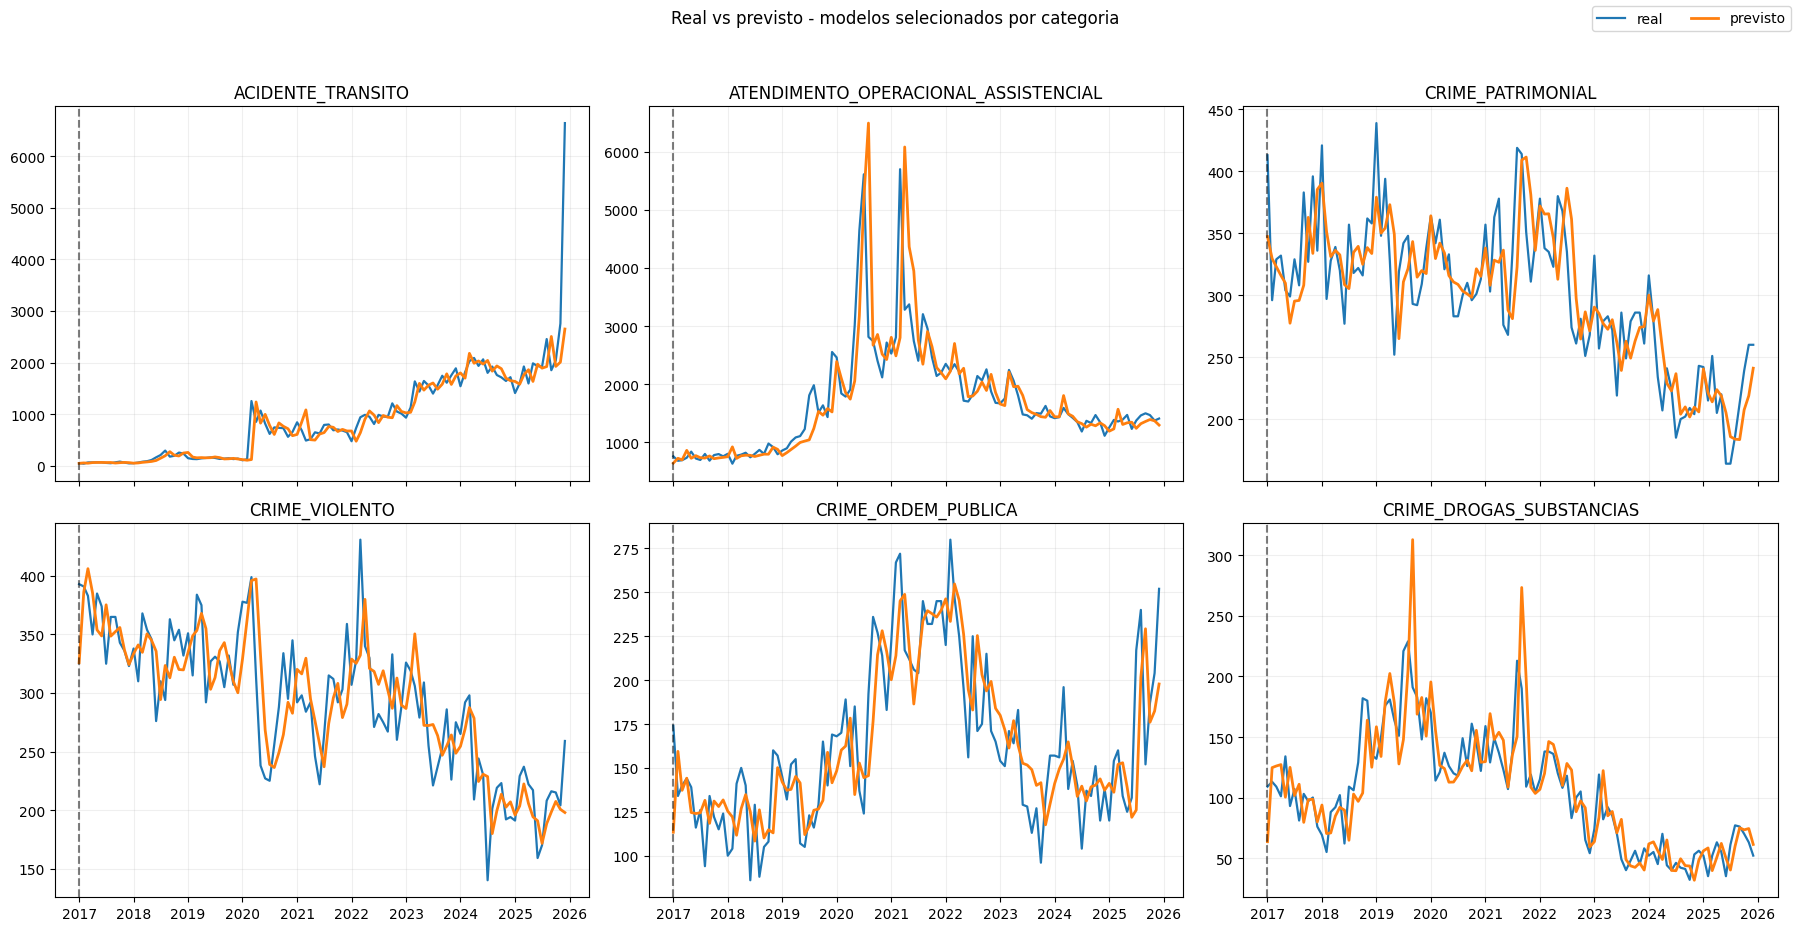

In [142]:
dados_reais_plot = (
    df_cat_modelos
    .groupby(['data', 'categoria'], as_index=False)
    .agg(real=('y', 'sum'))
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 9),
    sharex=True
)

axes = axes.ravel()

for ax, categoria in zip(axes, categorias_modelar):

    config = modelos_plot_categoria[categoria]
    predicoes = config['predicoes']
    tipo_modelo = config['tipo_modelo']

    pred_categoria_plot = (
        predicoes[
            predicoes['categoria'] == categoria
        ]
        .groupby(['data', 'categoria'], as_index=False)
        .agg(previsto=('y_pred', 'sum'))
    )

    tmp = dados_reais_plot[
        dados_reais_plot['categoria'] == categoria
    ].merge(
        pred_categoria_plot,
        on=['data', 'categoria'],
        how='inner'
    )

    params = obter_parametros_xgb_categoria(
        categoria=categoria,
        tipo_modelo=tipo_modelo
    )

    texto_params = (
        f'{tipo_modelo}\n'
        f'{formatar_parametros_grafico(params)}'
    )

    ax.plot(
        tmp['data'],
        tmp['real'],
        label='real',
        linewidth=1.6
    )

    ax.plot(
        tmp['data'],
        tmp['previsto'],
        label='previsto',
        linewidth=2
    )

    ax.axvline(
        pd.to_datetime('2017-01-01'),
        color='black',
        linestyle='--',
        alpha=0.5
    )

    ax.set_title(categoria)
    ax.grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=2)

fig.suptitle(
    'Real vs previsto - modelos selecionados por categoria',
    y=1.03
)

plt.tight_layout()
plt.show()